In [2]:
# using Pkg
# Pkg.add("Package") # Add single package
# Pkg.add(["PackageName", "PackageName", "PackageName", "PackageName", "PackageName"]) # Add multiple packages

In [3]:
using CSV, DataFrames, StatsPlots, Graphs, Statistics 
using StatsBase, Combinatorics, Dates, XLSX

In [2]:

# df = DataFrame(XLSX.readtable("/Users/oawolude/Networkshares/Datamanagement/Research/ID/ContactTracing/E_ResearchData/0_DataPreparation/1_SourceData/Contact_tracing_contextual_data.xlsx", "Data"))
# CSV.write("CT_contextual_data.csv", df)

### Import the CSV files

In [5]:

df_CCL = CSV.read("/Volumes/DATA/JC/Datamanagement/Research/ID/ContactTracing/E_ResearchData/0_DataPreparation/1_SourceData/case_contact_link.csv", DataFrame);

In [6]:

df_cases = CSV.read("/Volumes/DATA/JC/Datamanagement/Research/ID/ContactTracing/E_ResearchData/0_DataPreparation/1_SourceData/cases.csv", DataFrame);

In [7]:

df_contacts = CSV.read("/Volumes/DATA/JC/Datamanagement/Research/ID/ContactTracing/E_ResearchData/0_DataPreparation/1_SourceData/contacts.csv", DataFrame);

In [9]:
df_CT_Contextual = CSV.read("/Volumes/DATA/JC/Datamanagement/Research/ID/ContactTracing/E_ResearchData/0_DataPreparation/1_SourceData/CT_contextual_data.csv", DataFrame);

In [10]:
df_RIVM_Data = CSV.read("/Volumes/DATA/JC/Datamanagement/Research/ID/ContactTracing/E_ResearchData/0_DataPreparation/1_SourceData/COVID-19_aantallen_settings_per_dag.csv", DataFrame);

### Checking the column names in the CSV files

In [13]:
names(df_CCL)

6-element Vector{String}:
 "hash_case_number"
 "hash_contact_number"
 "Contact Catergory"
 "Positive Case"
 "Date Time Entered"
 "GGD_export"

In [14]:
rename!(df_CCL, :"Contact Catergory" => :"Contact Category");
names(df_CCL)

6-element Vector{String}:
 "hash_case_number"
 "hash_contact_number"
 "Contact Category"
 "Positive Case"
 "Date Time Entered"
 "GGD_export"

In [15]:
names(df_cases)

21-element Vector{String}:
 "Unique Identifier"
 "Type"
 "Date of Onset"
 "Osirisnummer"
 "Probable Transmission Route"
 "Relationship to the above case"
 "Degree of Contact"
 "Oorspronkelijke bron van de melding"
 "Datum melding aan de GGD"
 "Gender"
 "Age in Years (at date of onset)"
 "Age in Months (if a baby)"
 "hash_acht_pc"
 "hash_acht_pc_inval"
 "hash_case_identifier"
 "hash_unique_identifier"
 "hash_case_number"
 "hash_osiris_nr"
 "country_birth_hash"
 "PC4"
 "hash_contact_of_identifier"

In [16]:
names(df_contacts)

15-element Vector{String}:
 "Unique Identifier"
 "Type"
 "Relationship to the above case"
 "Degree of Contact"
 "Gender"
 "Age in Years (at date of onset)"
 "Age in Months (if a baby)"
 "hash_acht_pc"
 "hash_acht_pc_inval"
 "hash_case_identifier"
 "hash_unique_identifier"
 "hash_case_number"
 "country_birth_hash"
 "PC4"
 "hash_contact_of_identifier"

In [17]:
names(df_CT_Contextual)

6-element Vector{String}:
 "Date"
 "CT tier (see note)"
 "Stringency index"
 "CaseLoad"
 "FTE"
 "Load/FTE"

### Check the first five entries in each CSV file

In [18]:
first(df_CCL, 5)

Row,hash_case_number,hash_contact_number,Contact Category,Positive Case,Date Time Entered,GGD_export
,String,String,String3?,String1,String31,String15
1,0000f4abf6b7724542596cb34b0c6a31,0634706e24043278f3c3ff373ee5a231,1,Y,2020-07-28T02:26:00Z,GGD Amsterdam
2,0000f4abf6b7724542596cb34b0c6a31,027ffa4193f45c0a4c0833a639be3c7a,1,N,2020-07-28T02:26:00Z,GGD Amsterdam
3,0000f4abf6b7724542596cb34b0c6a31,b9d0eb728e1bf14869e743b64db2b2fc,2b,N,2020-07-28T02:26:00Z,GGD Amsterdam
4,0001a90c9ba39d1f510170143d2bc06e,cfc2fce6117d2412cdd50cf049375124,2a,N,2020-11-09T18:55:00Z,GGD Amsterdam
5,000429d2cf83d49c90833109faa3c7eb,3ecd1b19b0569d371cbc8d91bac65094,1,N,2021-04-14T19:37:00Z,GGD Amsterdam


In [19]:
first(df_contacts, 5)

Row,Unique Identifier,Type,Relationship to the above case,Degree of Contact,Gender,Age in Years (at date of onset),Age in Months (if a baby),hash_acht_pc,hash_acht_pc_inval,hash_case_identifier,hash_unique_identifier,hash_case_number,country_birth_hash,PC4,hash_contact_of_identifier
,String,String7,String31,String31,String3,String3,String3,String,Bool,String,String,String,String,String7,String
1,82e685fa-87c3-43b8-a975-d2e18fbf2487,Contact,Huisgenoot,Category 1: huishoudcontact,1,53,0,de735705a58e206ace58b36bbc0729d8,false,6080a3e2bb29c10909e43d0829b6257d,98daf4b72f6d81364af160c6021d8259,acf2d2fccb1df12ad11ef7be39972254,6807d0aaadbf53427fcf1561cdba8b4c,8,ea3388528ed4b3738715195d9d070062
2,a5253113-92e9-4ba8-a788-2b5dfead6110,Contact,Kind,"Category 2a: nauw contact, lang",2,85,0,df9dc975a4d26c87240d090008d9255f,false,e3c625a83bd4fc3655b53a56d8666e86,ebcf69664a70e36be64f78b75d28b194,bde89a1d880ffdf92bd9f3606e2f5554,d97ea96ee7ee126a4ec5c7980e610003,8,19f60527b7b1eb32f131d2a160ce5267
3,a42f152b-e005-4906-bd06-238747b821ed,Contact,Vriend of kennis,"Category 2a: nauw contact, lang",2,0,0,5deecf4fc29dcb39ee1465291640c43d,false,52c7648346f0a0611421073f4c976c37,5f7a737a051302f95651a5870072c18f,1abc47e736926f309b28e01440709ffe,d97ea96ee7ee126a4ec5c7980e610003,8,d1244532457bc7db6295e866fc72bde8
4,0ca88af3-d260-482a-8d82-b2559996e494,Contact,Vriend of kennis,"Category 2a: nauw contact, lang",1,30,0,e9e1e725579c026f5a4679f64596f2af,false,63ab80f1853720242eb05c39e6c38bb8,36b2f0bff5bb71231b28f58985f3bc0f,f0a40002e21a405bb2abe67430d5793b,d97ea96ee7ee126a4ec5c7980e610003,8,e1d2c172c633902c5a2aa8a23ddc62c6
5,c64364c1-b8e9-4c0d-bbc2-6dc8bccf4992,Contact,Partner,Category 1: huishoudcontact,2,60,0,b251eb4715db421000539c8782d85aa2,false,67ea479d87c8b347e0b04f88d2c05ad6,40f39f7c450b84fd1001b80c96f72d7c,e4ea9ccb328ab5a4c4c95c21265ba14d,d32513d9084882af370ebccbff38ea2b,9,081fc3322a11f16834349dd71ae6f27f


In [20]:
first(df_cases, 5)

Row,Unique Identifier,Type,Date of Onset,Osirisnummer,Probable Transmission Route,Relationship to the above case,Degree of Contact,Oorspronkelijke bron van de melding,Datum melding aan de GGD,Gender,Age in Years (at date of onset),Age in Months (if a baby),hash_acht_pc,hash_acht_pc_inval,hash_case_identifier,hash_unique_identifier,hash_case_number,hash_osiris_nr,country_birth_hash,PC4,hash_contact_of_identifier
,String,String7,String31,String7,String31,String31,String31,String31,String31,String3,String3,String3,String,Bool,String,String,String,String,String,String7,String
1,22496fd5-4e65-4524-a3ab-91d2208e84a5,Case,2021-05-20T00:00:00Z,4722872,NA,Partner,Category 1: huishoudcontact,Laboratorium,2021-05-20T00:00:00Z,2,61,0,fe4a045d0b3e0cf74bd5d2f545bf99a5,false,82a819a2fb85be7e74ce478506781948,82d615a2525ddf3fb111e5771a5b0fb3,af85b46d749fc7f37ff0372a47b6b45f,84abb27a7081e28ace2948d1e9b13b8b,6807d0aaadbf53427fcf1561cdba8b4c,1025,ff8f6fddbe7b2e26dc18e97150f05880
2,ede75132-a4fa-4234-8195-6ca95380bfdd,Case,2020-12-04T00:00:00Z,2562780,NA,Kind,Category 1: huishoudcontact,Laboratorium,2020-12-07T00:00:00Z,1,52,0,b049dc1495112ebad61630d62c147300,false,953684eba9bdcdef5cf9213287847130,1f483a02a08cbe08f362668e6a5be627,0d23d055dc17c0dabed0914312e18980,abb630e8e10091ed1153ea5629f3ae88,d97ea96ee7ee126a4ec5c7980e610003,1056,4de787188049777149976dfb311c3b2f
3,45efa613-3078-48a4-b8f8-c734a70c90c9,Case,2020-09-03T00:00:00Z,1560196,NA,Partner,Category 1: huishoudcontact,Laboratorium,2020-09-09T00:00:00Z,1,43,0,1a10f44f34d528c6020d90e47cd84e7d,false,57a88fc2c6103c0845895fc702683ea7,199414a0172894df93004ee9b43a5870,600ca1e549f55d32b18a71135b9c9846,84bb4612a0fb016973497e364c1e48cc,d97ea96ee7ee126a4ec5c7980e610003,1096,1460ab2956b221e9257c8ec05043e7cd
4,ce0ade39-31b2-4fcf-b62e-45dbe4dfa4a4,Case,2020-07-14T00:00:00Z,1497946,NA,Partner,Category 1: huishoudcontact,NA,2020-07-24T00:00:00Z,1,37,0,2a4d759d0fe03ef3b98b7adff8b1b79b,false,fc07fcec1fac7e66b798f9f24da17f4d,c6e41b4a0a1e31f2cc9d88c3003e7cbe,8c05f260b27a790091e4fa76fd811bb1,6d9fcdd9808d1727e0761d1ee6501e05,817f913ecb87fca3729ca42ead308485,1024,c102fe0f4a89932c8228e344220cc0a0
5,a1054696-3341-487e-9cd7-d9237786ff56,Case,2021-02-22T00:00:00Z,3612160,NA,Partner,Category 1: huishoudcontact,Laboratorium,2021-02-25T00:00:00Z,2,81,0,1b4c654e3e06d4048cd8de3fd5e3e303,false,d2862a5aa13314795e4339b5b4f5b8be,3e50a05e5a45f97cfe808a5a6ee3eb9b,f60fb5c2b5a7710b40d1924be3c505b3,df660af86f7e66a988081378a528eede,d97ea96ee7ee126a4ec5c7980e610003,1052,acb25137e8a986fecf032f26ce3cabc6


In [21]:
first(df_CT_Contextual, 5)

Row,Date,CT tier (see note),Stringency index,CaseLoad,FTE,Load/FTE
,Date,Float64?,Float64,Int64,Int64,Float64
1,2020-06-01,missing,62.96,114,26,4.38462
2,2020-06-02,missing,62.96,114,26,4.38462
3,2020-06-03,missing,62.96,114,26,4.38462
4,2020-06-04,missing,62.96,114,26,4.38462
5,2020-06-05,missing,62.96,114,26,4.38462


### Describe the CSV files

In [22]:
describe(df_CCL)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Nothing,Abstract…,Nothing,Abstract…,Int64,Type
1,hash_case_number,,0000f4abf6b7724542596cb34b0c6a31,,fffffbf3e2afb57cb20bdcbed0fc829e,0,String
2,hash_contact_number,,00009e8fb0d940a553382e4a571d5462,,ffff6c5f36e28dc9e9fc31737367844f,0,String
3,Contact Category,,1,,3,5949,"Union{Missing, String3}"
4,Positive Case,,N,,Y,0,String1
5,Date Time Entered,,2020-06-14T18:51:00Z,,2021-05-30T22:46:00Z,0,String31
6,GGD_export,,GGD Amsterdam,,GGD Amsterdam,0,String15


In [23]:
describe(df_contacts)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,Unique Identifier,,00004896-993e-418d-92f2-0ec8580eaf6c,,ffff175b-ab8a-4478-9f1f-b792d2c3babc,0,String
2,Type,,Contact,,Contact,0,String7
3,Relationship to the above case,,Broer of zus,,Vriend of kennis,0,String31
4,Degree of Contact,,Category 1: huishoudcontact,,Zorgverlener,0,String31
5,Gender,,0,,NA,0,String3
6,Age in Years (at date of onset),,0,,NA,0,String3
7,Age in Months (if a baby),,0,,NA,0,String3
8,hash_acht_pc,,00016324697937a7496ad163f323bd9b,,fffe3aaabcd77209239b246aedc3ed65,0,String
9,hash_acht_pc_inval,0.128125,false,0.0,true,0,Bool


In [24]:
describe(df_cases)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,Unique Identifier,,00010427-0564-45e1-874f-3552969b4039,,fffee76f-293c-48b6-b5af-4a1e9528c719,0,String
2,Type,,Case,,Case,0,String7
3,Date of Onset,,2019-07-31T00:00:00Z,,NA,0,String31
4,Osirisnummer,,1482808,,NA,0,String7
5,Probable Transmission Route,,Aerogeen,,Onbekend,0,String31
6,Relationship to the above case,,Broer of zus,,Vriend/kennis,0,String31
7,Degree of Contact,,Category 1: huishoudcontact,,Overig,0,String31
8,Oorspronkelijke bron van de melding,,AWBZ zorginstelling,,Ziekenhuis,0,String31
9,Datum melding aan de GGD,,1900-01-02T00:00:00Z,,NA,0,String31


### Check number of rows in each CSV file

In [25]:
nrow(df_CCL)

125623

In [26]:
nrow(df_cases)

102347

In [27]:
nrow(df_contacts)

86275

### Check number of unique cases and contacts

In [28]:
length(unique(df_CCL.hash_case_number))

47235

In [29]:
length(unique(df_CCL.hash_contact_number))

105540

### Group contacts per case

In [30]:

# This tells you how many contacts each case has.

# DISTRIBUTION

# SHAPE               INTERPRETATION

# narrow peak  -->    homogeneous mixing

# long tail    -->    heterogeneity / superspreaders

# heavy tail   -->    possible clustering

contacts_per_case = combine(groupby(df_CCL, :hash_case_number), nrow => :num_contacts)


Row,hash_case_number,num_contacts
,String,Int64
1,0000f4abf6b7724542596cb34b0c6a31,3
2,0001a90c9ba39d1f510170143d2bc06e,1
3,000429d2cf83d49c90833109faa3c7eb,12
4,0004d3a3793c77726b08a61ef9b76cec,2
5,000548e29e0fa1ee9e4778718089eea1,1
6,0007ea028ebbee911c56c87ba75e226c,1
7,0008cb5e2b47626fc8ccc03775336a6a,1
8,000954f4a864f41c1003502a12937c0e,1
9,0009aef3734b180b2d42f4d918b25671,2


In [31]:
describe(contacts_per_case)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,hash_case_number,,0000f4abf6b7724542596cb34b0c6a31,,fffffbf3e2afb57cb20bdcbed0fc829e,0,String
2,num_contacts,2.65953,1,2.0,67,0,Int64


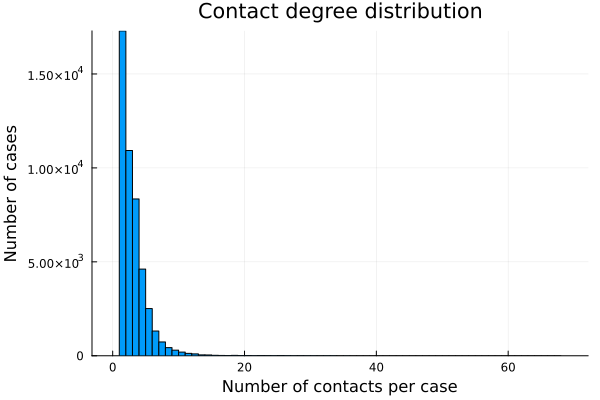

In [32]:
@df contacts_per_case histogram(
    :num_contacts,
    bins = 100,
    xlabel = "Number of contacts per case",
    ylabel = "Number of cases",
    title = "Contact degree distribution",
    legend = false
)

This is a right-skewed (long tail) distribution which means contact behaviour is HETEROGENEOUS.

### Number of contacts that later became cases

In [33]:
intersect(unique(df_CCL.hash_case_number), unique(df_CCL.hash_contact_number))

9939-element Vector{String}:
 "000548e29e0fa1ee9e4778718089eea1"
 "0012427d2c6535848a82b46f23fc70bf"
 "001fab4e8e9b0473c4a2a72756ac0d98"
 "0021b2dc712759dc1475498cfeed3f6e"
 "0038af18f4cb2322056d6c299e50f6d1"
 "003fba9da98a90309ea42c5afb4bbd91"
 "0042467e5146adf468c7a15c67621b78"
 "00427d9667c33d009fe24f1b591ac18e"
 "0044be0447e6900af51964e8e6f194d4"
 "0046e59c81526b7205bf928c755e15ce"
 "004fe669235b57d0dcacccf590eaed21"
 "0055660d6359f61db1059c6aa04bcc17"
 "005fc39fc77d12e3375cac5176d16051"
 ⋮
 "ffca473c5bef4ee2b03330283a926dc1"
 "ffcb17352148231f275eaa5842c05a4e"
 "ffcbe3a61bf4268575a8e51c3039f577"
 "ffccbf5576daeab76623c013ce6ab5bf"
 "ffccc917e0e627e9ee90a22ae442ebdc"
 "ffd46649ca80d4d4b008b2d1db3260b3"
 "ffd7548f4d3c82e38a86fbeeb06bba22"
 "ffdb9102eaa05cba0664e6cf3494b35d"
 "ffdd5e3dcd9b12dc723b69933b61c749"
 "ffdf77915caeffbe0d32adfc06aae99a"
 "fff636bad094ec365e4edacb7eb39135"
 "fffb5c951b91fff282c8ef3f8aad28fa"

### Shared contacts between cases

In [34]:
# This directly reveals overlapping neighbourhoods, which create clustering.

# DISTRIBUTION

# SHAPE               INTERPRETATION

# Mostly 1    -->     tree-like transmission

# Many > 1    -->     overlapping social contacts

# Long tail   -->     clustering / shared environments

cases_per_contact = combine(groupby(df_CCL, :hash_contact_number), nrow => :num_cases)


Row,hash_contact_number,num_cases
,String,Int64
1,0634706e24043278f3c3ff373ee5a231,1
2,027ffa4193f45c0a4c0833a639be3c7a,2
3,b9d0eb728e1bf14869e743b64db2b2fc,1
4,cfc2fce6117d2412cdd50cf049375124,1
5,3ecd1b19b0569d371cbc8d91bac65094,1
6,89f26b25915eafa733e07112b19e1180,1
7,15cf8627d3ad10861d0c55c7c0a71c1b,1
8,3f2cb5410d85022baf83b917312aa18d,1
9,a1deac33a327567838c02a8bd277fee4,1


In [35]:
describe(cases_per_contact)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,hash_contact_number,,00009e8fb0d940a553382e4a571d5462,,ffff6c5f36e28dc9e9fc31737367844f,0,String
2,num_cases,1.19029,1,1.0,10,0,Int64


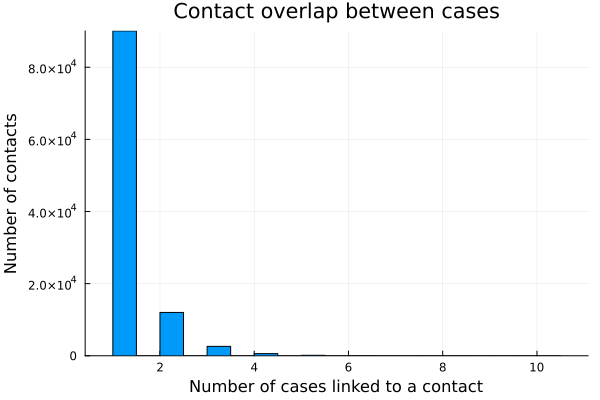

In [36]:
@df cases_per_contact histogram(
    :num_cases,
    bins = 40,
    xlabel = "Number of cases linked to a contact",
    ylabel = "Number of contacts",
    title = "Contact overlap between cases",
    legend = false
)

In [37]:
#length(vcat(case_nodes, contact_nodes))

## Case-Contact Network Bipartite Incidence Network

In [38]:
# We have two sets of identifiers in the links data:
# hash_case_number -> case IDs
# hash_contact_number -> contact IDs

case_nodes    = ["case:" * string(x) for x in df_CCL.hash_case_number]
contact_nodes = ["contact:" * string(x) for x in df_CCL.hash_contact_number];

In [39]:
# The case and contact IDs reperesent individuals in the network. So we need a single list of all individuals.
nodes = unique(vcat(case_nodes, contact_nodes));

In [40]:
# The IDs in the data set are strings but to convert the data set to graph network
# requires node labels to be integers.

# So we map the person ID -> interger index ID
node_map = Dict(node => i for (i, node) in enumerate(nodes));

In [41]:
g_bip = SimpleGraph(length(nodes))

# We build a bipartite graph from the list of nodes and then add edges where there are connections. 
for r in eachrow(df_CCL)
    u = node_map["case:" * string(r.hash_case_number)]
    v = node_map["contact:" * string(r.hash_contact_number)]
    add_edge!(g_bip, u, v)
end

In [42]:
global_clustering_coefficient(g_bip)

0.0

In [43]:
case_degree_list = degree(g_bip)[1:length(case_nodes)]


125623-element Vector{Int64}:
  3
  1
 12
  2
  1
  1
  1
  1
  2
  3
  1
  1
  3
  ⋮
  1
  2
  1
  1
  1
  1
  1
  1
  1
  1
  1
  1

In [44]:
case_degree_df = combine(groupby(df_CCL, :hash_case_number), nrow => :contacts_per_case)

Row,hash_case_number,contacts_per_case
,String,Int64
1,0000f4abf6b7724542596cb34b0c6a31,3
2,0001a90c9ba39d1f510170143d2bc06e,1
3,000429d2cf83d49c90833109faa3c7eb,12
4,0004d3a3793c77726b08a61ef9b76cec,2
5,000548e29e0fa1ee9e4778718089eea1,1
6,0007ea028ebbee911c56c87ba75e226c,1
7,0008cb5e2b47626fc8ccc03775336a6a,1
8,000954f4a864f41c1003502a12937c0e,1
9,0009aef3734b180b2d42f4d918b25671,2


In [45]:
case_degree_df[case_degree_df.contacts_per_case .== maximum(case_degree_df.contacts_per_case), :]

Row,hash_case_number,contacts_per_case
,String,Int64
1,4fbd8080e157331fd04a69d4721d1bf9,67


In [46]:
findall(case_degree_df.contacts_per_case .== maximum(case_degree_df.contacts_per_case))

1-element Vector{Int64}:
 14635

In [47]:
degree_freq_table = combine(groupby(case_degree_df, :contacts_per_case), nrow => :Frequency)

Row,contacts_per_case,Frequency
,Int64,Int64
1,1,17292
2,2,10926
3,3,8347
4,4,4614
5,5,2512
6,6,1316
7,7,737
8,8,434
9,9,300


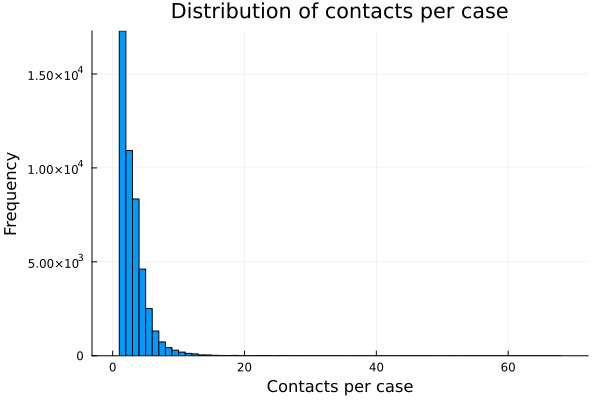

In [48]:
histogram(case_degree_df.contacts_per_case,
          bins = 100,
          xlabel = "Contacts per case",
          ylabel = "Frequency",
          title = "Distribution of contacts per case",
          label = nothing)
#savefig("contacts_per_case_BP_Network.png")

# plot!(degree_freq_table.contacts_per_case, degree_freq_table.Frequency, 
#       marker = :circle, 
#       lw = 2, 
#       color = :red,
#       label = "Curve")

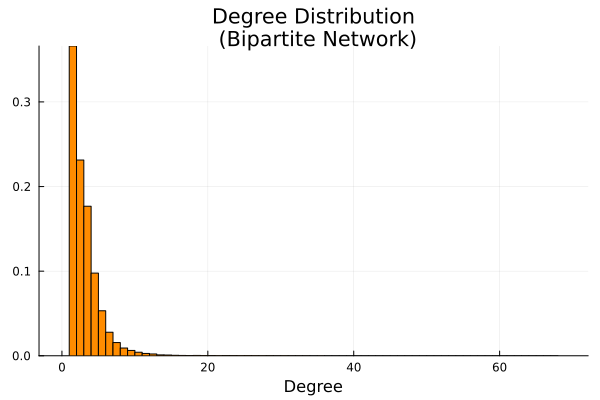

In [49]:
histogram(case_degree_df.contacts_per_case,
    bins = 100,
    normalize =:pdf,
    xlabel = "Degree",
    color = :darkorange,
    label = nothing,
    title = "Degree Distribution\n (Bipartite Network)"
)
#savefig("Degree_dist_BP_Network.png")

### Proportion of contacts that became secondary cases

In [50]:
contacts_status = combine(groupby(df_CCL, :hash_contact_number), "Positive Case" => first => :positive)

Row,hash_contact_number,positive
,String,String1
1,0634706e24043278f3c3ff373ee5a231,Y
2,027ffa4193f45c0a4c0833a639be3c7a,N
3,b9d0eb728e1bf14869e743b64db2b2fc,N
4,cfc2fce6117d2412cdd50cf049375124,N
5,3ecd1b19b0569d371cbc8d91bac65094,N
6,89f26b25915eafa733e07112b19e1180,N
7,15cf8627d3ad10861d0c55c7c0a71c1b,N
8,3f2cb5410d85022baf83b917312aa18d,N
9,a1deac33a327567838c02a8bd277fee4,N


In [51]:
# Secondary Attack Rate (SAR)

# SAR = Number of secondary cases among contacts / Total number of susceptible contacts exposed
SAR = mean(contacts_status.positive .== "Y")

0.18867727875686943

In [52]:
countmap(contacts_status.positive)

Dict{String1, Int64} with 2 entries:
  "Y" => 19913
  "N" => 85627

In [53]:
19913/(19913+85627) * 100

18.867727875686942

In [54]:
g_bip

{152775, 125623} undirected simple Int64 graph

In [55]:
g_bip_component_sizes = length.(connected_components(g_bip))

35575-element Vector{Int64}:
  5
  2
 13
  3
 39
 10
 15
  2
  3
  4
  2
  2
  4
  ⋮
  3
  2
  2
  2
  4
  2
  4
  2
  6
  4
  2
  4

In [56]:
sort(g_bip_component_sizes)

35575-element Vector{Int64}:
  2
  2
  2
  2
  2
  2
  2
  2
  2
  2
  2
  2
  2
  ⋮
 60
 61
 62
 63
 68
 74
 76
 81
 88
 90
 96
 97

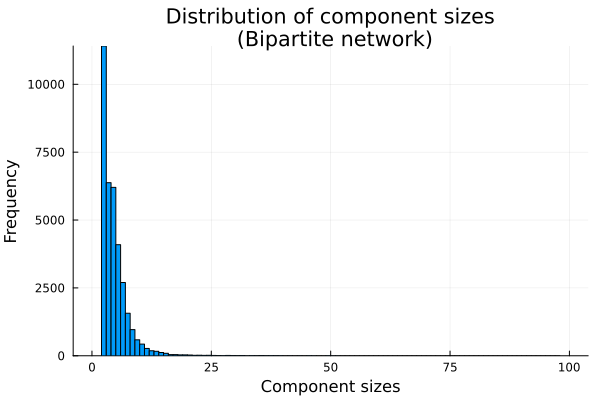

In [57]:
histogram(g_bip_component_sizes, 
        bins =100, 
        label=nothing,
        xlabel = "Component sizes",
        ylabel = "Frequency",
        title = "Distribution of component sizes\n (Bipartite network)")

#savefig("Comp_size_BP_Network.png")

In [58]:
global_clustering_coefficient(g_bip)

0.0

## Person-Level Network

* This is a a person-level observed contact/exposure network induced by the tracing data.

* Here, each unique identifier is one individual.

* An edge means that individual appeared in a case–contact link with another individual.

In [59]:
# We have two sets of identifiers in the links data:
# hash_case_number -> case IDs
# hash_contact_number -> contact IDs

# The case and contact IDs reperesent individuals in the network. So we need a single list of all individuals.

nodes_PLu_Network = unique(vcat(df_CCL.hash_case_number, df_CCL.hash_contact_number))


142836-element Vector{String}:
 "0000f4abf6b7724542596cb34b0c6a31"
 "0001a90c9ba39d1f510170143d2bc06e"
 "000429d2cf83d49c90833109faa3c7eb"
 "0004d3a3793c77726b08a61ef9b76cec"
 "000548e29e0fa1ee9e4778718089eea1"
 "0007ea028ebbee911c56c87ba75e226c"
 "0008cb5e2b47626fc8ccc03775336a6a"
 "000954f4a864f41c1003502a12937c0e"
 "0009aef3734b180b2d42f4d918b25671"
 "0009bc83805c3a2c215a34a34c298f3b"
 "0009c877a50c985e17a1a50d15c858e8"
 "000ca2e9decc819edb78942b6615cf59"
 "000f4936778f8f80e4838e8d322f596d"
 ⋮
 "bc99f81b62344abbc0bca5ff160eeddd"
 "89094d20199ae92e0274b41b0268f0cd"
 "5d8cb420501e60e2ad74531d05e78f9d"
 "170bf0e8d917a652c7845b73b025cb22"
 "a2afd23d1f84cd78a3761388f9ae5a9b"
 "608a04fc45325fb3df79c8f561991f79"
 "a1a539650f018c21ae03474a42ffb56e"
 "67386e7253d76604ed41b2ae500078a5"
 "438ffbce3197ca976cd9f51d31cea069"
 "4ec702f77dd9238e2ad010e19a4fdf98"
 "ab43a4efd08f1ff24d180020b0f87053"
 "dc2ed3ee10d915824cd4f4c1e22fca61"

In [60]:
# The IDs in the data set are strings but to convert the data set to graph network
# requires node labels to be integers.

# So we map the person ID -> interger index ID

node_map_PLu_Network = Dict()

for i in eachindex(nodes_PLu_Network)
    node_map_PLu_Network[nodes_PLu_Network[i]] = i
end
node_map_PLu_Network

#node_map_PLu_Network = node_map_person = Dict(id => i for (i, id) in enumerate(nodes_PLu_Network))

Dict{Any, Any} with 142836 entries:
  "58ac468802be8fed4f5eae4e97c78574" => 74901
  "11440f650b07e988cbad1a94117bca09" => 74470
  "9346d16379dd3d8dbbc84d4d6020cb9d" => 101930
  "b0c72902bea8f26cacfc28ca0fb7dfae" => 32783
  "da20e200902cb02b7ee9a1c6c32c7f83" => 40318
  "f8e48e080490f403e94f8fb4f9bba3c6" => 61499
  "97b83d426a134b4c26fe42d167fcd791" => 27960
  "c137c6fbfce73dfcf3acb8b080177a1e" => 35806
  "d0693ae08b4f3ef2c31f0fe79a6dacdd" => 95968
  "0e133d62f0776c73b94d175193ee8bb2" => 101829
  "4fa683df72c141aaf631ac19cad6a52a" => 103188
  "5e22a8a2805362536a2f751c93a37f72" => 111362
  "bfab3407cf1b8fe06bc09504bf8af799" => 123313
  "6c2ccf9b48bd7eab26217db5533a38b4" => 101660
  "70c8c83a86c0e49d91681427b0c3bc90" => 20702
  "3d0fc71978ea2675cab119bbdf226bdd" => 120208
  "d4afeb60e87e1aacdbf470e73dca4aae" => 39292
  "e27bad93143563c93ed0bc789fb5b471" => 41851
  "3d5506dc6de43722b12d059620e04a3c" => 11166
  "a78f989eba0a8622f5988e6f078eb348" => 116786
  "59d434dc5dcd31cea3c367b41d47af7b"

In [61]:
# We build a graph from the list nodes and then add edges where there are connections. 

PLu_Network = SimpleGraph(length(nodes_PLu_Network))

for r in eachrow(df_CCL)
    add_edge!(PLu_Network, node_map_PLu_Network[r.hash_case_number], node_map_PLu_Network[r.hash_contact_number])
end

In [62]:
# Easily view connections (edges) in each row of the data set
r1 = df_CCL[1, :]
(node_map_PLu_Network[r1.hash_case_number], node_map_PLu_Network[r1.hash_contact_number])

(1, 1094)

In [63]:
PLu_Network

{142836, 125621} undirected simple Int64 graph

In [64]:
global_clustering_coefficient(PLu_Network)

0.15085754640839386

In [65]:
# Connected components in the network
PLu_components = connected_components(PLu_Network)

32724-element Vector{Vector{Int64}}:
 [1, 1094, 47236, 47237]
 [2, 47238]
 [3, 20557, 47239, 47240, 47241, 47242, 47243, 47244, 47245, 47246, 47247, 47248, 47249, 92891]
 [4, 47250, 47251]
 [5, 2129, 5695, 16929, 27589, 28221, 28451, 35706, 38214, 41559  …  132622, 132623, 132624, 132625, 132626, 132627, 132628, 132629, 132630, 132631]
 [6, 33442, 37244, 39869, 47253, 124963, 124964, 124965, 124966]
 [7, 6323, 19571, 27300, 33597, 33951, 39710, 47254, 106245, 118258, 118259]
 [8, 47255]
 [9, 47256, 47257]
 [10, 47258, 47259, 47260]
 [11, 47261]
 [12, 47262]
 [13, 47263, 47264, 47265]
 ⋮
 [47214, 142809, 142810]
 [47217, 142811]
 [47221, 142812]
 [47222, 142813]
 [47223, 142814, 142815, 142816]
 [47225, 142818]
 [47227, 142820, 142821, 142822]
 [47228, 142823]
 [47230, 142824, 142825, 142826, 142827, 142828]
 [47232, 142829, 142830, 142831]
 [47234, 142833]
 [47235, 142834, 142835, 142836]

In [66]:
# Size of each component in the network
PLu_component_sizes = length.(PLu_components)

32724-element Vector{Int64}:
  4
  2
 14
  3
 54
  9
 11
  2
  3
  4
  2
  2
  4
  ⋮
  3
  2
  2
  2
  4
  2
  4
  2
  6
  4
  2
  4

In [67]:
sort(countmap(PLu_component_sizes))

OrderedCollections.OrderedDict{Int64, Int64} with 68 entries:
  2  => 9684
  3  => 6461
  4  => 6247
  5  => 3839
  6  => 2263
  7  => 1280
  8  => 773
  9  => 534
  10 => 352
  11 => 282
  12 => 196
  13 => 145
  14 => 111
  15 => 78
  16 => 69
  17 => 53
  18 => 38
  19 => 29
  20 => 25
  21 => 30
  22 => 24
  23 => 20
  24 => 13
  25 => 12
  26 => 19
  ⋮  => ⋮

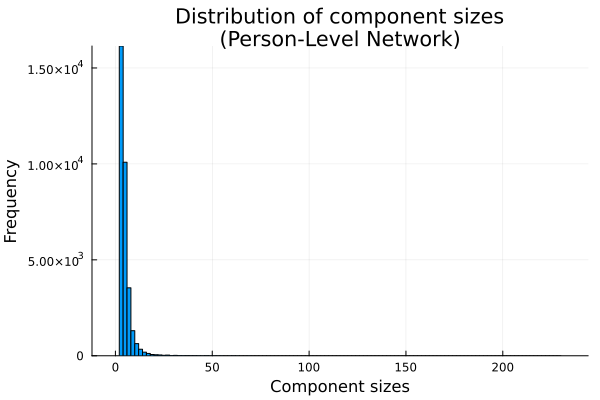

In [68]:
histogram(PLu_component_sizes, 
        bins =200, 
        label=nothing,
        xlabel = "Component sizes",
        ylabel = "Frequency",
        title = "Distribution of component sizes\n(Person-Level Network)")

#savefig("Comp_size_PLU_Network.png")

In [69]:
PLu_components[PLu_component_sizes .== minimum(PLu_component_sizes), :]

9684×1 Matrix{Vector{Int64}}:
 [2, 47238]
 [8, 47255]
 [11, 47261]
 [12, 47262]
 [15, 47269]
 [24, 47282]
 [29, 47291]
 [33, 47298]
 [35, 47300]
 [37, 47303]
 [52, 47337]
 [53, 47338]
 [54, 47339]
 ⋮
 [47168, 142734]
 [47183, 142759]
 [47186, 142763]
 [47194, 142768]
 [47198, 142773]
 [47210, 142792]
 [47217, 142811]
 [47221, 142812]
 [47222, 142813]
 [47225, 142818]
 [47228, 142823]
 [47234, 142833]

In [70]:
PLu_largest_component =  PLu_components[findall(PLu_component_sizes .== maximum(PLu_component_sizes))][1]

228-element Vector{Int64}:
    758
    867
    936
   1327
   1898
   4061
   4617
   5204
   5555
   5735
   6096
   6861
   8975
      ⋮
 126619
 129806
 131441
 131442
 131443
 135239
 136457
 136863
 136864
 136865
 137909
 141154

In [71]:
deg_PLu_Network = degree(PLu_Network)

142836-element Vector{Int64}:
  3
  1
 12
  2
  3
  1
  1
  1
  2
  3
  1
  1
  3
  ⋮
  1
  1
  1
  1
  1
  1
  1
  1
  1
  1
  1
  1

In [72]:
sort(countmap(deg_PLu_Network))

OrderedCollections.OrderedDict{Int64, Int64} with 43 entries:
  1  => 95075
  2  => 21894
  3  => 12418
  4  => 6260
  5  => 3065
  6  => 1604
  7  => 837
  8  => 537
  9  => 321
  10 => 223
  11 => 145
  12 => 102
  13 => 66
  14 => 37
  15 => 34
  16 => 22
  17 => 18
  18 => 21
  19 => 15
  20 => 13
  21 => 10
  22 => 13
  23 => 16
  24 => 10
  25 => 15
  ⋮  => ⋮

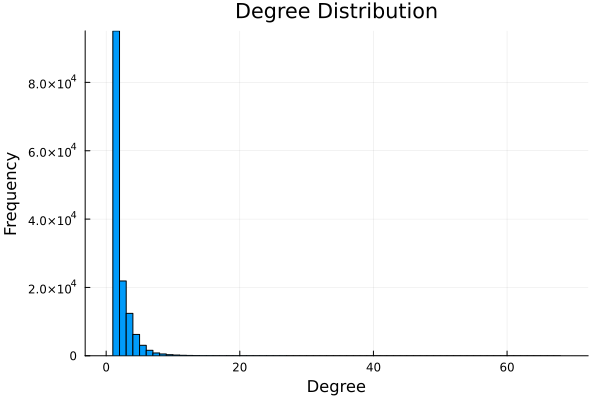

In [73]:
histogram(
    deg_PLu_Network,
    bins = 100,
    xlabel = "Degree",
    ylabel = "Frequency",
    label = nothing,
    title = "Degree Distribution"
)

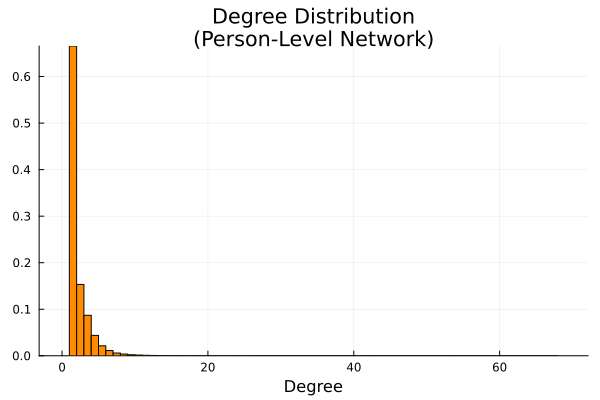

In [74]:
histogram(
    deg_PLu_Network,
    bins = 100,
    normalize =:pdf,
    xlabel = "Degree",
    color = :darkorange,
    label = nothing,
    title = "Degree Distribution\n(Person-Level Network)"
)
#savefig("Degree_dist_PLU_Network.png")

### Percentage of components that contain any clustering

In [75]:
n_total = length(PLu_components)
n_clustered = 0

for comp in PLu_components
    subg, _ = induced_subgraph(PLu_Network, comp)

    if nv(subg) >= 3 && global_clustering_coefficient(subg) > 0
        n_clustered += 1
    end
end

pct_clustered_components = 100 * n_clustered / n_total

println("Total components = ", n_total)
println("Clustered components = ", n_clustered)
println("Percentage clustered = ", round(pct_clustered_components, digits=2), "%")

Total components = 32724
Clustered components = 4963
Percentage clustered = 15.17%


### Percentage of clustering that comes from each component

#### Total triangles in the graph

In [76]:
PLu_total_triangles = sum(triangles(PLu_Network)) / 3
println("Total triangles = ", PLu_total_triangles)

Total triangles = 14953.0


#### Triangle and clustering in each component

In [77]:
PLu_comp_stats = DataFrame(
    component_id = Int[],
    size = Int[],
    triangles = Float64[],
    triplets = Float64[],
    pct_of_all_triangles = Float64[], 
    comp_clustering_coeff = Float64[]
)

for (i, comp) in enumerate(PLu_components)
    subg, _ = induced_subgraph(PLu_Network, comp)
    ntri = sum(triangles(subg)) / 3
    ntriplets = sum(degree(subg) .* (degree(subg) .- 1)) / 2


    push!(PLu_comp_stats, (
        i,
        nv(subg),
        ntri,
        ntriplets,
        PLu_total_triangles == 0 ? 0.0 : 100 * ntri / PLu_total_triangles,
         global_clustering_coefficient(subg)
    ))
end

In [78]:
PLu_comp_stats

Row,component_id,size,triangles,triplets,pct_of_all_triangles,comp_clustering_coeff
,Int64,Int64,Float64,Float64,Float64,Float64
1,1,4,1.0,5.0,0.00668762,0.6
2,2,2,0.0,0.0,0.0,1.0
3,3,14,0.0,67.0,0.0,0.0
4,4,3,0.0,1.0,0.0,0.0
5,5,54,4.0,285.0,0.0267505,0.0421053
6,6,9,1.0,18.0,0.00668762,0.166667
7,7,11,3.0,39.0,0.0200629,0.230769
8,8,2,0.0,0.0,0.0,1.0
9,9,3,0.0,1.0,0.0,0.0


In [79]:
sort!(PLu_comp_stats, :pct_of_all_triangles, rev=true)
first(PLu_comp_stats, 10)

Row,component_id,size,triangles,triplets,pct_of_all_triangles,comp_clustering_coeff
,Int64,Int64,Float64,Float64,Float64,Float64
1,752,228,426.0,4109.0,2.84893,0.311025
2,633,42,166.0,1264.0,1.11015,0.393987
3,4704,13,134.0,542.0,0.896141,0.741697
4,5416,52,67.0,682.0,0.448071,0.294721
5,2467,21,47.0,289.0,0.314318,0.487889
6,4378,23,41.0,261.0,0.274192,0.471264
7,4639,12,38.0,224.0,0.25413,0.508929
8,15515,41,38.0,531.0,0.25413,0.214689
9,8107,8,34.0,123.0,0.227379,0.829268


In [80]:
sum(PLu_comp_stats.triangles)

14953.0

In [81]:
sum(PLu_comp_stats.triplets)

297360.0

In [82]:
# Global clustering Coefficient = (3 * Total Triangles)/Total Triplets
# Triangle - 3 nodes, 3 edges (fully connected)
# Triplet - 3 nodes, 2 edges (connected through a center node)

(3*sum(PLu_comp_stats.triangles))/sum(PLu_comp_stats.triplets)

0.15085754640839386

### Proportion of contacts that became secondary cases

In [83]:
PLu_contacts_status = combine(groupby(df_CCL, :hash_contact_number), "Positive Case" => first => :positive)

Row,hash_contact_number,positive
,String,String1
1,0634706e24043278f3c3ff373ee5a231,Y
2,027ffa4193f45c0a4c0833a639be3c7a,N
3,b9d0eb728e1bf14869e743b64db2b2fc,N
4,cfc2fce6117d2412cdd50cf049375124,N
5,3ecd1b19b0569d371cbc8d91bac65094,N
6,89f26b25915eafa733e07112b19e1180,N
7,15cf8627d3ad10861d0c55c7c0a71c1b,N
8,3f2cb5410d85022baf83b917312aa18d,N
9,a1deac33a327567838c02a8bd277fee4,N


In [84]:
# Secondary Attack Rate (SAR)

# SAR = Number of secondary cases among contacts / Total number of susceptible contacts exposed

#  SAR among contact-nodes
SAR = mean(PLu_contacts_status.positive .== "Y")
println("SAR = ", SAR)

SAR = 0.18867727875686943


In [85]:
println("SAR = ", round(100 * SAR, digits=2), "%")

SAR = 18.87%


In [86]:
countmap(PLu_contacts_status.positive)

Dict{String1, Int64} with 2 entries:
  "Y" => 19913
  "N" => 85627

In [87]:
n_contacts = nrow(PLu_contacts_status)
n_secondary = sum(PLu_contacts_status.positive .== "Y")
n_not_secondary = sum(PLu_contacts_status.positive .== "N")

println("Total contacts = ", n_contacts)
println("Secondary cases = ", n_secondary)
println("Non-cases = ", n_not_secondary)
println("SAR = ", round(100 * n_secondary / n_contacts, digits=2), "%")

Total contacts = 105540
Secondary cases = 19913
Non-cases = 85627
SAR = 18.87%


### For contacts of the same case, how often do contact–contact links exist, conditional on their infection status?

* Infected <-> Infected (YY)

* Infected <-> Susceptible (YN)

* Susceptible <-> Susceptible (NN)

In [88]:
PLu_contacts_status_copy = deepcopy(PLu_contacts_status);

In [89]:
rename!(PLu_contacts_status_copy, :hash_contact_number => :person_id)

Row,person_id,positive
,String,String1
1,0634706e24043278f3c3ff373ee5a231,Y
2,027ffa4193f45c0a4c0833a639be3c7a,N
3,b9d0eb728e1bf14869e743b64db2b2fc,N
4,cfc2fce6117d2412cdd50cf049375124,N
5,3ecd1b19b0569d371cbc8d91bac65094,N
6,89f26b25915eafa733e07112b19e1180,N
7,15cf8627d3ad10861d0c55c7c0a71c1b,N
8,3f2cb5410d85022baf83b917312aa18d,N
9,a1deac33a327567838c02a8bd277fee4,N


In [90]:
PLu_status_map = Dict(
    row.person_id => row.positive
    for row in eachrow(PLu_contacts_status_copy)
)

Dict{String, String1} with 105540 entries:
  "58ac468802be8fed4f5eae4e97c78574" => "N"
  "11440f650b07e988cbad1a94117bca09" => "N"
  "9346d16379dd3d8dbbc84d4d6020cb9d" => "N"
  "da20e200902cb02b7ee9a1c6c32c7f83" => "Y"
  "4fa683df72c141aaf631ac19cad6a52a" => "N"
  "f8e48e080490f403e94f8fb4f9bba3c6" => "Y"
  "d0693ae08b4f3ef2c31f0fe79a6dacdd" => "Y"
  "0e133d62f0776c73b94d175193ee8bb2" => "N"
  "5e22a8a2805362536a2f751c93a37f72" => "N"
  "bfab3407cf1b8fe06bc09504bf8af799" => "N"
  "6c2ccf9b48bd7eab26217db5533a38b4" => "Y"
  "70c8c83a86c0e49d91681427b0c3bc90" => "Y"
  "3d0fc71978ea2675cab119bbdf226bdd" => "N"
  "d4afeb60e87e1aacdbf470e73dca4aae" => "Y"
  "e27bad93143563c93ed0bc789fb5b471" => "Y"
  "3d5506dc6de43722b12d059620e04a3c" => "Y"
  "a78f989eba0a8622f5988e6f078eb348" => "N"
  "59d434dc5dcd31cea3c367b41d47af7b" => "Y"
  "7ec5d8b8819bd42831bfcbf549c3510c" => "N"
  "a222d8c236816e59b577eeab16e968df" => "N"
  "8708df76fcb57081d463cb379afb007b" => "N"
  "92ea875faa8ad8b158569c337d4914

In [91]:
PLu_df_use = df_CCL

Row,hash_case_number,hash_contact_number,Contact Category,Positive Case,Date Time Entered,GGD_export
,String,String,String3?,String1,String31,String15
1,0000f4abf6b7724542596cb34b0c6a31,0634706e24043278f3c3ff373ee5a231,1,Y,2020-07-28T02:26:00Z,GGD Amsterdam
2,0000f4abf6b7724542596cb34b0c6a31,027ffa4193f45c0a4c0833a639be3c7a,1,N,2020-07-28T02:26:00Z,GGD Amsterdam
3,0000f4abf6b7724542596cb34b0c6a31,b9d0eb728e1bf14869e743b64db2b2fc,2b,N,2020-07-28T02:26:00Z,GGD Amsterdam
4,0001a90c9ba39d1f510170143d2bc06e,cfc2fce6117d2412cdd50cf049375124,2a,N,2020-11-09T18:55:00Z,GGD Amsterdam
5,000429d2cf83d49c90833109faa3c7eb,3ecd1b19b0569d371cbc8d91bac65094,1,N,2021-04-14T19:37:00Z,GGD Amsterdam
6,000429d2cf83d49c90833109faa3c7eb,89f26b25915eafa733e07112b19e1180,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
7,000429d2cf83d49c90833109faa3c7eb,15cf8627d3ad10861d0c55c7c0a71c1b,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
8,000429d2cf83d49c90833109faa3c7eb,3f2cb5410d85022baf83b917312aa18d,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
9,000429d2cf83d49c90833109faa3c7eb,a1deac33a327567838c02a8bd277fee4,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam


In [92]:
PLu_counts_total = Dict(
    "YN" => 0,
    "YY" => 0,
    "NN" => 0
)

PLu_counts_edges = Dict(
    "YN" => 0,
    "YY" => 0,
    "NN" => 0
)

Dict{String, Int64} with 3 entries:
  "YY" => 0
  "YN" => 0
  "NN" => 0

In [93]:
for subdf in groupby(PLu_df_use, :hash_case_number)

    contacts = unique(subdf.hash_contact_number)

    # Only consider pairs
    if length(contacts) < 2
        continue
    end

    for (u_id, v_id) in combinations(contacts, 2)

        # Skip if status missing
        if !haskey(PLu_status_map, u_id) || !haskey(PLu_status_map, v_id)
            continue
        end

        su = PLu_status_map[u_id]
        sv = PLu_status_map[v_id]

        if su == "Y" && sv == "Y"
            key = "YY"
        elseif su == "N" && sv == "N"
            key = "NN"
        else
            key = "YN"
        end

        PLu_counts_total[key] += 1

        # Check if edge exists in person-level graph
        if has_edge(PLu_Network, node_map_PLu_Network[u_id], node_map_PLu_Network[v_id])
            PLu_counts_edges[key] += 1
        end
    end
end

In [94]:
PLu_counts_total

Dict{String, Int64} with 3 entries:
  "YY" => 11075
  "YN" => 41671
  "NN" => 189409

In [95]:
PLu_counts_edges

Dict{String, Int64} with 3 entries:
  "YY" => 4258
  "YN" => 10662
  "NN" => 14

In [96]:
# Pair type             Interpretation
#    YY            clustering among infected contacts
#    YN            mixing between infected and susceptible
#    NN            clustering among susceptible contacts


println("----- RESULTS -----")

for key in ["YY", "YN", "NN"]
    total = PLu_counts_total[key]
    edges = PLu_counts_edges[key]

    prop = total == 0 ? 0.0 : edges / total

    println(key, ": ", round(100 * prop, digits=2), "%")
end

----- RESULTS -----
YY: 38.45%
YN: 25.59%
NN: 0.01%


## Adding Household links to Person-Level Network

In [97]:
PLHHu_Network= deepcopy(PLu_Network)

PLHHu_df_household = df_CCL[coalesce.(df_CCL."Contact Category", "") .== "1", :]

for subdf in groupby(PLHHu_df_household, :hash_case_number)
    contacts = unique(subdf.hash_contact_number)

    contact_nodes = [
        node_map_PLu_Network[id]
        for id in contacts
        if haskey(node_map_PLu_Network, id)
    ]

    if length(contact_nodes) > 1
        for (u, v) in combinations(contact_nodes, 2)
            add_edge!(PLHHu_Network, u, v)
        end
    end
end

In [98]:
PLHHu_Network

{142836, 168302} undirected simple Int64 graph

In [99]:
global_clustering_coefficient(PLHHu_Network)

0.5726796902008114

In [100]:
# Household clique edges

ne(PLHHu_Network)-ne(PLu_Network)

42681

In [101]:
PLHHu_components = connected_components(PLHHu_Network)

32724-element Vector{Vector{Int64}}:
 [1, 1094, 47236, 47237]
 [2, 47238]
 [3, 20557, 47239, 47240, 47241, 47242, 47243, 47244, 47245, 47246, 47247, 47248, 47249, 92891]
 [4, 47250, 47251]
 [5, 2129, 5695, 16929, 27589, 28221, 28451, 35706, 38214, 41559  …  132622, 132623, 132624, 132625, 132626, 132627, 132628, 132629, 132630, 132631]
 [6, 33442, 37244, 39869, 47253, 124963, 124964, 124965, 124966]
 [7, 6323, 19571, 27300, 33597, 33951, 39710, 47254, 106245, 118258, 118259]
 [8, 47255]
 [9, 47256, 47257]
 [10, 47258, 47259, 47260]
 [11, 47261]
 [12, 47262]
 [13, 47263, 47264, 47265]
 ⋮
 [47214, 142809, 142810]
 [47217, 142811]
 [47221, 142812]
 [47222, 142813]
 [47223, 142814, 142815, 142816]
 [47225, 142818]
 [47227, 142820, 142821, 142822]
 [47228, 142823]
 [47230, 142824, 142825, 142826, 142827, 142828]
 [47232, 142829, 142830, 142831]
 [47234, 142833]
 [47235, 142834, 142835, 142836]

In [102]:
# Size of each component in the network
PLHHu_component_sizes = length.(PLHHu_components)

32724-element Vector{Int64}:
  4
  2
 14
  3
 54
  9
 11
  2
  3
  4
  2
  2
  4
  ⋮
  3
  2
  2
  2
  4
  2
  4
  2
  6
  4
  2
  4

In [103]:
sort(countmap(PLHHu_component_sizes))

OrderedCollections.OrderedDict{Int64, Int64} with 68 entries:
  2  => 9684
  3  => 6461
  4  => 6247
  5  => 3839
  6  => 2263
  7  => 1280
  8  => 773
  9  => 534
  10 => 352
  11 => 282
  12 => 196
  13 => 145
  14 => 111
  15 => 78
  16 => 69
  17 => 53
  18 => 38
  19 => 29
  20 => 25
  21 => 30
  22 => 24
  23 => 20
  24 => 13
  25 => 12
  26 => 19
  ⋮  => ⋮

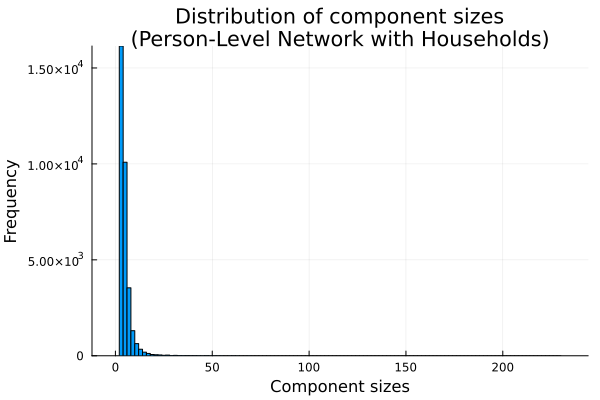

In [104]:
histogram(PLHHu_component_sizes, 
        bins =200, 
        label=nothing,
        xlabel = "Component sizes",
        ylabel = "Frequency",
        title = "Distribution of component sizes\n(Person-Level Network with Households)")

#savefig("Comp_size_PLHHU_Network.png")

In [105]:
deg_PLHHu_Network= degree(PLHHu_Network);

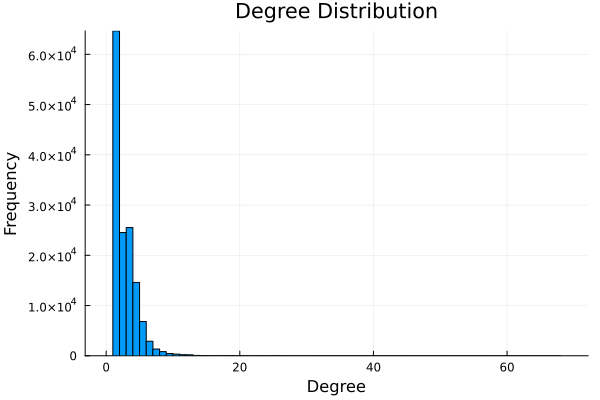

In [106]:
histogram(
    deg_PLHHu_Network,
    bins = 100,
    xlabel = "Degree",
    ylabel = "Frequency",
    label = nothing,
    title = "Degree Distribution"
)

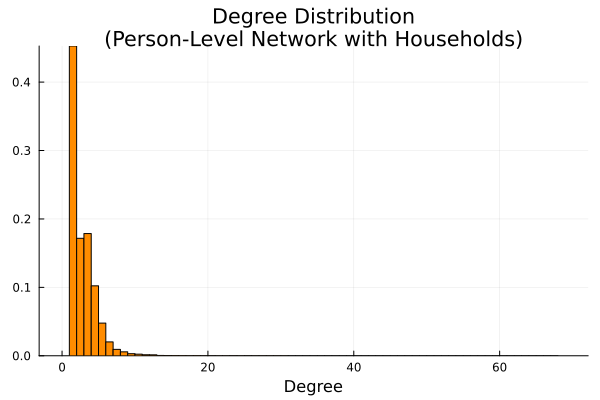

In [107]:
histogram(
    deg_PLHHu_Network,
    bins = 100,
    normalize =:pdf,
    xlabel = "Degree",
    label = nothing,
    color = :darkorange,
    title = "Degree Distribution\n(Person-Level Network with Households)"
)
#savefig("Degree_dist_PLHHU_Network.png")

### Percentage of components that contain any clustering

In [108]:
n_total = length(PLHHu_components)
n_clustered = 0

for comp in PLHHu_components
    subg, _ = induced_subgraph(PLHHu_Network, comp)

    if nv(subg) >= 3 && global_clustering_coefficient(subg) > 0
        n_clustered += 1
    end
end

pct_clustered_components = 100 * n_clustered / n_total

println("Total components = ", n_total)
println("Clustered components = ", n_clustered)
println("Percentage clustered = ", round(pct_clustered_components, digits=2), "%")

Total components = 32724
Clustered components = 15541
Percentage clustered = 47.49%


### Percentage of clustering that comes from each component

#### Total triangles in the graph

In [109]:
PLHHu_total_triangles = sum(triangles(PLHHu_Network)) / 3
println("Total triangles = ", PLHHu_total_triangles)

Total triangles = 94424.0


#### Triangle and clustering in each component

In [110]:
PLHHu_comp_stats = DataFrame(
    component_id = Int[],
    size = Int[],
    triangles = Float64[],
    triplets = Float64[],
    pct_of_all_triangles = Float64[], 
    comp_clustering_coeff = Float64[]
)

for (i, comp) in enumerate(PLHHu_components)
    subg, _ = induced_subgraph(PLHHu_Network, comp)
    ntri = sum(triangles(subg)) / 3
    ntriplets = sum(degree(subg) .* (degree(subg) .- 1)) / 2


    push!(PLHHu_comp_stats, (
        i,
        nv(subg),
        ntri,
        ntriplets,
        PLHHu_total_triangles == 0 ? 0.0 : 100 * ntri / PLHHu_total_triangles,
         global_clustering_coefficient(subg)
    ))
end

In [111]:
PLHHu_comp_stats

Row,component_id,size,triangles,triplets,pct_of_all_triangles,comp_clustering_coeff
,Int64,Int64,Float64,Float64,Float64,Float64
1,1,4,1.0,5.0,0.00105905,0.6
2,2,2,0.0,0.0,0.0,1.0
3,3,14,0.0,67.0,0.0,0.0
4,4,3,0.0,1.0,0.0,0.0
5,5,54,218.0,1071.0,0.230874,0.610644
6,6,9,1.0,18.0,0.00105905,0.166667
7,7,11,42.0,168.0,0.0444802,0.75
8,8,2,0.0,0.0,0.0,1.0
9,9,3,1.0,3.0,0.00105905,1.0


In [112]:
sort!(PLHHu_comp_stats, :pct_of_all_triangles, rev=true)
first(PLHHu_comp_stats, 10)

Row,component_id,size,triangles,triplets,pct_of_all_triangles,comp_clustering_coeff
,Int64,Int64,Float64,Float64,Float64,Float64
1,11255,21,969.0,2926.0,1.02622,0.993506
2,15515,41,684.0,2248.0,0.724392,0.912811
3,9051,27,572.0,1995.0,0.605778,0.86015
4,4192,16,560.0,1680.0,0.59307,1.0
5,752,228,541.0,4478.0,0.572948,0.362439
6,6154,28,464.0,1469.0,0.4914,0.947583
7,8418,36,287.0,1017.0,0.303948,0.846608
8,15256,13,286.0,858.0,0.302889,1.0
9,15657,16,275.0,872.0,0.29124,0.946101


In [113]:
sum(PLHHu_comp_stats.triangles)

94424.0

In [114]:
sum(PLHHu_comp_stats.triplets)

494643.0

In [115]:
# Global clustering Coefficient = (3 * Total Triangles)/Total Triplets
# Triangle - 3 nodes, 3 edges (fully connected)
# Triplet - 3 nodes, 2 edges (connected through a center node)

(3*sum(PLHHu_comp_stats.triangles))/sum(PLHHu_comp_stats.triplets)

0.5726796902008114

### For contacts of the same case, how often do contact–contact links exist, conditional on their infection status?

* Infected <-> Infected (YY)

* Infected <-> Susceptible (YN)

* Susceptible <-> Susceptible (NN)

In [116]:
PLHHu_contacts_status_copy = deepcopy(PLu_contacts_status);

In [117]:
rename!(PLHHu_contacts_status_copy, :hash_contact_number => :person_id)

Row,person_id,positive
,String,String1
1,0634706e24043278f3c3ff373ee5a231,Y
2,027ffa4193f45c0a4c0833a639be3c7a,N
3,b9d0eb728e1bf14869e743b64db2b2fc,N
4,cfc2fce6117d2412cdd50cf049375124,N
5,3ecd1b19b0569d371cbc8d91bac65094,N
6,89f26b25915eafa733e07112b19e1180,N
7,15cf8627d3ad10861d0c55c7c0a71c1b,N
8,3f2cb5410d85022baf83b917312aa18d,N
9,a1deac33a327567838c02a8bd277fee4,N


In [118]:
PLHHu_status_map = Dict(
    row.person_id => row.positive
    for row in eachrow(PLHHu_contacts_status_copy)
)

Dict{String, String1} with 105540 entries:
  "58ac468802be8fed4f5eae4e97c78574" => "N"
  "11440f650b07e988cbad1a94117bca09" => "N"
  "9346d16379dd3d8dbbc84d4d6020cb9d" => "N"
  "da20e200902cb02b7ee9a1c6c32c7f83" => "Y"
  "4fa683df72c141aaf631ac19cad6a52a" => "N"
  "f8e48e080490f403e94f8fb4f9bba3c6" => "Y"
  "d0693ae08b4f3ef2c31f0fe79a6dacdd" => "Y"
  "0e133d62f0776c73b94d175193ee8bb2" => "N"
  "5e22a8a2805362536a2f751c93a37f72" => "N"
  "bfab3407cf1b8fe06bc09504bf8af799" => "N"
  "6c2ccf9b48bd7eab26217db5533a38b4" => "Y"
  "70c8c83a86c0e49d91681427b0c3bc90" => "Y"
  "3d0fc71978ea2675cab119bbdf226bdd" => "N"
  "d4afeb60e87e1aacdbf470e73dca4aae" => "Y"
  "e27bad93143563c93ed0bc789fb5b471" => "Y"
  "3d5506dc6de43722b12d059620e04a3c" => "Y"
  "a78f989eba0a8622f5988e6f078eb348" => "N"
  "59d434dc5dcd31cea3c367b41d47af7b" => "Y"
  "7ec5d8b8819bd42831bfcbf549c3510c" => "N"
  "a222d8c236816e59b577eeab16e968df" => "N"
  "8708df76fcb57081d463cb379afb007b" => "N"
  "92ea875faa8ad8b158569c337d4914

In [119]:
PLHHu_df_use = df_CCL

Row,hash_case_number,hash_contact_number,Contact Category,Positive Case,Date Time Entered,GGD_export
,String,String,String3?,String1,String31,String15
1,0000f4abf6b7724542596cb34b0c6a31,0634706e24043278f3c3ff373ee5a231,1,Y,2020-07-28T02:26:00Z,GGD Amsterdam
2,0000f4abf6b7724542596cb34b0c6a31,027ffa4193f45c0a4c0833a639be3c7a,1,N,2020-07-28T02:26:00Z,GGD Amsterdam
3,0000f4abf6b7724542596cb34b0c6a31,b9d0eb728e1bf14869e743b64db2b2fc,2b,N,2020-07-28T02:26:00Z,GGD Amsterdam
4,0001a90c9ba39d1f510170143d2bc06e,cfc2fce6117d2412cdd50cf049375124,2a,N,2020-11-09T18:55:00Z,GGD Amsterdam
5,000429d2cf83d49c90833109faa3c7eb,3ecd1b19b0569d371cbc8d91bac65094,1,N,2021-04-14T19:37:00Z,GGD Amsterdam
6,000429d2cf83d49c90833109faa3c7eb,89f26b25915eafa733e07112b19e1180,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
7,000429d2cf83d49c90833109faa3c7eb,15cf8627d3ad10861d0c55c7c0a71c1b,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
8,000429d2cf83d49c90833109faa3c7eb,3f2cb5410d85022baf83b917312aa18d,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
9,000429d2cf83d49c90833109faa3c7eb,a1deac33a327567838c02a8bd277fee4,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam


In [120]:
PLHHu_counts_total = Dict(
    "YN" => 0,
    "YY" => 0,
    "NN" => 0
)

PLHHu_counts_edges = Dict(
    "YN" => 0,
    "YY" => 0,
    "NN" => 0
)

Dict{String, Int64} with 3 entries:
  "YY" => 0
  "YN" => 0
  "NN" => 0

In [121]:
for subdf in groupby(PLHHu_df_use, :hash_case_number)

    contacts = unique(subdf.hash_contact_number)

    # Only consider pairs
    if length(contacts) < 2
        continue
    end

    for (u_id, v_id) in combinations(contacts, 2)

        # Skip if status missing
        if !haskey(PLHHu_status_map, u_id) || !haskey(PLHHu_status_map, v_id)
            continue
        end

        su = PLHHu_status_map[u_id]
        sv = PLHHu_status_map[v_id]

        if su == "Y" && sv == "Y"
            key = "YY"
        elseif su == "N" && sv == "N"
            key = "NN"
        else
            key = "YN"
        end

        PLHHu_counts_total[key] += 1

        # Check if edge exists in person-level graph
        if has_edge(PLHHu_Network, node_map_PL_Network[u_id], node_map_PL_Network[v_id])
            PLHHu_counts_edges[key] += 1
        end
    end
end

LoadError: UndefVarError: `node_map_PL_Network` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [ ]:
PLHHu_counts_total

Dict{String, Int64} with 3 entries:
  "YY" => 0
  "YN" => 1
  "NN" => 0

In [ ]:
PLHHu_counts_edges

Dict{String, Int64} with 3 entries:
  "YY" => 0
  "YN" => 0
  "NN" => 0

In [ ]:
# Pair type             Interpretation
#    YY            clustering among infected contacts
#    YN            mixing between infected and susceptible
#    NN            clustering among susceptible contacts


println("----- RESULTS -----")

for key in ["YY", "YN", "NN"]
    total = PLHHu_counts_total[key]
    edges = PLHHu_counts_edges[key]

    prop = total == 0 ? 0.0 : edges / total

    println(key, ": ", round(100 * prop, digits=2), "%")
end

----- RESULTS -----
YY: 0.0%
YN: 0.0%
NN: 0.0%


## Person-Level Network (Clean)

Without Missing Data

* This is a a person-level observed contact/exposure network induced by the tracing data.

* Here, each unique identifier is one individual.

* An edge means that individual appeared in a case–contact link with another individual.

In [ ]:
df_CCL_Clean = df_CCL[.!ismissing.(df_CCL."Contact Category"), :]

Row,hash_case_number,hash_contact_number,Contact Category,Positive Case,Date Time Entered,GGD_export
,String,String,String3?,String1,String31,String15
1,0000f4abf6b7724542596cb34b0c6a31,0634706e24043278f3c3ff373ee5a231,1,Y,2020-07-28T02:26:00Z,GGD Amsterdam
2,0000f4abf6b7724542596cb34b0c6a31,027ffa4193f45c0a4c0833a639be3c7a,1,N,2020-07-28T02:26:00Z,GGD Amsterdam
3,0000f4abf6b7724542596cb34b0c6a31,b9d0eb728e1bf14869e743b64db2b2fc,2b,N,2020-07-28T02:26:00Z,GGD Amsterdam
4,0001a90c9ba39d1f510170143d2bc06e,cfc2fce6117d2412cdd50cf049375124,2a,N,2020-11-09T18:55:00Z,GGD Amsterdam
5,000429d2cf83d49c90833109faa3c7eb,3ecd1b19b0569d371cbc8d91bac65094,1,N,2021-04-14T19:37:00Z,GGD Amsterdam
6,000429d2cf83d49c90833109faa3c7eb,89f26b25915eafa733e07112b19e1180,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
7,000429d2cf83d49c90833109faa3c7eb,15cf8627d3ad10861d0c55c7c0a71c1b,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
8,000429d2cf83d49c90833109faa3c7eb,3f2cb5410d85022baf83b917312aa18d,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
9,000429d2cf83d49c90833109faa3c7eb,a1deac33a327567838c02a8bd277fee4,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam


In [ ]:
countmap(df_CCL_Clean.var"Contact Category")

Dict{Union{Missing, String3}, Int64} with 4 entries:
  String3("1")  => 72178
  String3("2a") => 44644
  String3("2b") => 2059
  String3("3")  => 793

In [ ]:
# We have two sets of identifiers in the links data:
# hash_case_number -> case IDs
# hash_contact_number -> contact IDs

# The case and contact IDs reperesent individuals in the network. So we need a single list of all individuals.

nodes_PL_Network = unique(vcat(df_CCL_Clean.hash_case_number, df_CCL_Clean.hash_contact_number))


136592-element Vector{String}:
 "0000f4abf6b7724542596cb34b0c6a31"
 "0001a90c9ba39d1f510170143d2bc06e"
 "000429d2cf83d49c90833109faa3c7eb"
 "0004d3a3793c77726b08a61ef9b76cec"
 "000548e29e0fa1ee9e4778718089eea1"
 "0007ea028ebbee911c56c87ba75e226c"
 "0008cb5e2b47626fc8ccc03775336a6a"
 "000954f4a864f41c1003502a12937c0e"
 "0009aef3734b180b2d42f4d918b25671"
 "0009bc83805c3a2c215a34a34c298f3b"
 "0009c877a50c985e17a1a50d15c858e8"
 "000ca2e9decc819edb78942b6615cf59"
 "000f4936778f8f80e4838e8d322f596d"
 ⋮
 "bc99f81b62344abbc0bca5ff160eeddd"
 "89094d20199ae92e0274b41b0268f0cd"
 "5d8cb420501e60e2ad74531d05e78f9d"
 "170bf0e8d917a652c7845b73b025cb22"
 "a2afd23d1f84cd78a3761388f9ae5a9b"
 "608a04fc45325fb3df79c8f561991f79"
 "a1a539650f018c21ae03474a42ffb56e"
 "67386e7253d76604ed41b2ae500078a5"
 "438ffbce3197ca976cd9f51d31cea069"
 "4ec702f77dd9238e2ad010e19a4fdf98"
 "ab43a4efd08f1ff24d180020b0f87053"
 "dc2ed3ee10d915824cd4f4c1e22fca61"

In [ ]:
# The IDs in the data set are strings but to convert the data set to graph network
# requires node labels to be integers.

# So we map the person ID -> interger index ID

node_map_PL_Network = Dict()

for i in eachindex(nodes_PL_Network)
    node_map_PL_Network[nodes_PL_Network[i]] = i
end

node_map_PL_Network

Dict{Any, Any} with 136592 entries:
  "58ac468802be8fed4f5eae4e97c78574" => 70751
  "11440f650b07e988cbad1a94117bca09" => 70326
  "9346d16379dd3d8dbbc84d4d6020cb9d" => 96964
  "b0c72902bea8f26cacfc28ca0fb7dfae" => 30497
  "da20e200902cb02b7ee9a1c6c32c7f83" => 37485
  "f8e48e080490f403e94f8fb4f9bba3c6" => 57756
  "97b83d426a134b4c26fe42d167fcd791" => 26022
  "c137c6fbfce73dfcf3acb8b080177a1e" => 33293
  "0e133d62f0776c73b94d175193ee8bb2" => 96865
  "4fa683df72c141aaf631ac19cad6a52a" => 98185
  "5e22a8a2805362536a2f751c93a37f72" => 106091
  "bfab3407cf1b8fe06bc09504bf8af799" => 117657
  "6c2ccf9b48bd7eab26217db5533a38b4" => 96698
  "70c8c83a86c0e49d91681427b0c3bc90" => 19282
  "3d0fc71978ea2675cab119bbdf226bdd" => 114664
  "d4afeb60e87e1aacdbf470e73dca4aae" => 36544
  "e27bad93143563c93ed0bc789fb5b471" => 38922
  "3d5506dc6de43722b12d059620e04a3c" => 10417
  "a78f989eba0a8622f5988e6f078eb348" => 111334
  "59d434dc5dcd31cea3c367b41d47af7b" => 15356
  "4a2e5f46dd93c531a454c4f932a836c5" => 

In [ ]:
# We build a graph from the list nodes and then add edges where there are connections. 

PL_Network = SimpleGraph(length(nodes_PL_Network))

for r in eachrow(df_CCL_Clean)
    add_edge!(PL_Network, node_map_PL_Network[r.hash_case_number], node_map_PL_Network[r.hash_contact_number])
end

In [ ]:
# Easily view connections (edges) in each row of the data set
r1 = df_CCL_Clean[20, :]
(node_map_PL_Network[r1.hash_case_number], node_map_PL_Network[r1.hash_contact_number])

(6, 43926)

In [ ]:
global_clustering_coefficient(PL_Network)

0.1421146691303681

In [ ]:
# Connected components in the network
PL_components = connected_components(PL_Network)

31281-element Vector{Vector{Int64}}:
 [1, 1014, 43909, 43910]
 [2, 43911]
 [3, 19145, 43912, 43913, 43914, 43915, 43916, 43917, 43918, 43919, 43920, 43921, 43922, 88180]
 [4, 43923, 43924]
 [5, 1977, 5311, 15792, 25674, 26270, 26482, 33201, 35545, 38645  …  126703, 126704, 126705, 126706, 126707, 126708, 126709, 126710, 126711, 126712]
 [6, 31106, 34635, 37069, 43926, 119270, 119271, 119272, 119273]
 [7, 5896, 18230, 25407, 31244, 31568, 36925, 43927, 101115, 112769, 112770]
 [8, 43928]
 [9, 43929, 43930]
 [10, 43931, 43932, 43933]
 [11, 43934]
 [12, 43935]
 [13, 43936, 43937, 43938]
 ⋮
 [43888, 136563, 136564, 136565]
 [43889, 136566, 136567]
 [43892, 136568]
 [43895, 136569]
 [43896, 136570, 136571, 136572]
 [43898, 136574]
 [43900, 136576, 136577, 136578]
 [43901, 136579]
 [43903, 136580, 136581, 136582, 136583, 136584]
 [43905, 136585, 136586, 136587]
 [43907, 136589]
 [43908, 136590, 136591, 136592]

In [ ]:
# Size of each component in the network
PL_component_sizes = length.(PL_components)

31281-element Vector{Int64}:
  4
  2
 14
  3
 54
  9
 11
  2
  3
  4
  2
  2
  4
  ⋮
  4
  3
  2
  2
  4
  2
  4
  2
  6
  4
  2
  4

In [ ]:
sort(countmap(PL_component_sizes))

OrderedCollections.OrderedDict{Int64, Int64} with 64 entries:
  2  => 8745
  3  => 6236
  4  => 6176
  5  => 3815
  6  => 2270
  7  => 1237
  8  => 740
  9  => 542
  10 => 332
  11 => 272
  12 => 189
  13 => 136
  14 => 100
  15 => 83
  16 => 47
  17 => 49
  18 => 38
  19 => 26
  20 => 31
  21 => 20
  22 => 20
  23 => 21
  24 => 12
  25 => 9
  26 => 14
  ⋮  => ⋮

In [ ]:
PL_components[PL_component_sizes .== minimum(PL_component_sizes), :]

8745×1 Matrix{Vector{Int64}}:
 [2, 43911]
 [8, 43928]
 [11, 43934]
 [12, 43935]
 [15, 43942]
 [22, 43954]
 [27, 43963]
 [31, 43970]
 [33, 43972]
 [47, 44006]
 [48, 44007]
 [56, 44032]
 [64, 44051]
 ⋮
 [43824, 136462]
 [43840, 136488]
 [43845, 136494]
 [43846, 136495]
 [43847, 136496]
 [43870, 136527]
 [43885, 136550]
 [43892, 136568]
 [43895, 136569]
 [43898, 136574]
 [43901, 136579]
 [43907, 136589]

In [ ]:
PL_largest_component =  PL_components[findall(PL_component_sizes .== maximum(PL_component_sizes))][1]

187-element Vector{Int64}:
   2883
   4307
   4553
   4861
   5460
   5860
   6151
   8849
   9026
  10253
  11892
  14507
  14908
      ⋮
 129213
 129214
 129215
 129216
 129217
 130094
 131076
 131077
 131078
 131079
 136339
 136340

In [ ]:
deg_PL_Network = degree(PL_Network)

136592-element Vector{Int64}:
  3
  1
 12
  2
  3
  1
  1
  1
  2
  3
  1
  1
  3
  ⋮
  1
  1
  1
  1
  1
  1
  1
  1
  1
  1
  1
  1

In [ ]:
sort(countmap(deg_PL_Network))

OrderedCollections.OrderedDict{Int64, Int64} with 43 entries:
  1  => 91142
  2  => 20738
  3  => 11951
  4  => 6032
  5  => 2919
  6  => 1474
  7  => 778
  8  => 508
  9  => 294
  10 => 203
  11 => 141
  12 => 91
  13 => 53
  14 => 37
  15 => 28
  16 => 18
  17 => 17
  18 => 19
  19 => 13
  20 => 13
  21 => 8
  22 => 13
  23 => 16
  24 => 7
  25 => 16
  ⋮  => ⋮

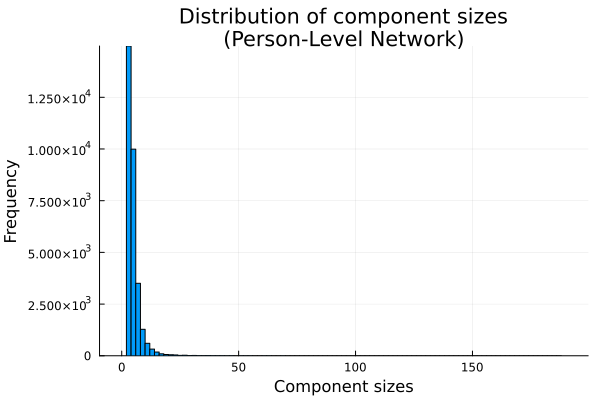

In [ ]:
histogram(PL_component_sizes, 
        bins =100, 
        label=nothing,
        xlabel = "Component sizes",
        ylabel = "Frequency",
        title = "Distribution of component sizes\n(Person-Level Network)")

#savefig("Comp_size_PLHHU_Network.png")

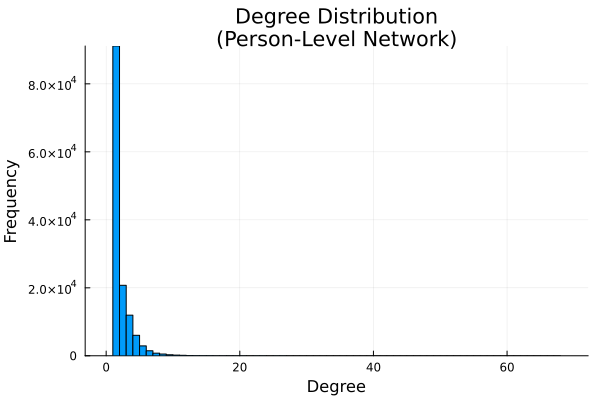

In [ ]:
histogram(
    deg_PL_Network,
    bins = 100,
    xlabel = "Degree",
    ylabel = "Frequency",
    label = nothing,
    title = "Degree Distribution\n(Person-Level Network)"
)

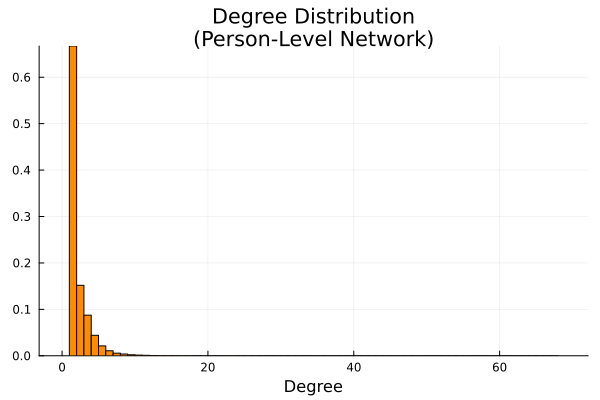

In [ ]:
histogram(
    deg_PL_Network,
    bins = 100,
    normalize =:pdf,
    xlabel = "Degree",
    label = nothing,
    color = :darkorange,
    title = "Degree Distribution\n(Person-Level Network)"
)

### Percentage of components that contain any clustering

In [ ]:
n_total = length(PL_components)
n_clustered = 0

for comp in PL_components
    subg, _ = induced_subgraph(PL_Network, comp)

    if nv(subg) >= 3 && global_clustering_coefficient(subg) > 0
        n_clustered += 1
    end
end

pct_clustered_components = 100 * n_clustered / n_total

println("Total components = ", n_total)
println("Clustered components = ", n_clustered)
println("Percentage clustered = ", round(pct_clustered_components, digits=2), "%")

Total components = 31281
Clustered components = 4525
Percentage clustered = 14.47%


### Percentage of clustering that comes from each component

#### Total triangles in the graph

In [ ]:
PL_total_triangles = sum(triangles(PL_Network)) / 3
println("Total triangles = ", PL_total_triangles)

Total triangles = 13280.0


#### Triangle and clustering in each component

In [ ]:
PL_comp_stats = DataFrame(
    component_id = Int[],
    size = Int[],
    triangles = Float64[],
    triplets = Float64[],
    pct_of_all_triangles = Float64[], 
    comp_clustering_coeff = Float64[]
)

for (i, comp) in enumerate(PL_components)
    subg, _ = induced_subgraph(PL_Network, comp)
    ntri = sum(triangles(subg)) / 3
    ntriplets = sum(degree(subg) .* (degree(subg) .- 1)) / 2


    push!(PL_comp_stats, (
        i,
        nv(subg),
        ntri,
        ntriplets,
        PL_total_triangles == 0 ? 0.0 : 100 * ntri / PL_total_triangles,
         global_clustering_coefficient(subg)
    ))
end

In [ ]:
PL_comp_stats

Row,component_id,size,triangles,triplets,pct_of_all_triangles,comp_clustering_coeff
,Int64,Int64,Float64,Float64,Float64,Float64
1,1,4,1.0,5.0,0.00753012,0.6
2,2,2,0.0,0.0,0.0,1.0
3,3,14,0.0,67.0,0.0,0.0
4,4,3,0.0,1.0,0.0,0.0
5,5,54,4.0,285.0,0.0301205,0.0421053
6,6,9,1.0,18.0,0.00753012,0.166667
7,7,11,3.0,39.0,0.0225904,0.230769
8,8,2,0.0,0.0,0.0,1.0
9,9,3,0.0,1.0,0.0,0.0


In [ ]:
sort!(PL_comp_stats, :pct_of_all_triangles, rev=true)
first(PL_comp_stats, 10)

Row,component_id,size,triangles,triplets,pct_of_all_triangles,comp_clustering_coeff
,Int64,Int64,Float64,Float64,Float64,Float64
1,696,34,376.0,2816.0,2.83133,0.400568
2,4416,13,134.0,542.0,1.00904,0.741697
3,2290,21,47.0,289.0,0.353916,0.487889
4,4353,12,38.0,224.0,0.286145,0.508929
5,14671,41,38.0,531.0,0.286145,0.214689
6,7619,8,34.0,123.0,0.256024,0.829268
7,4921,16,31.0,248.0,0.233434,0.375
8,10299,15,27.0,153.0,0.203313,0.529412
9,8722,8,26.0,98.0,0.195783,0.795918


In [ ]:
sum(PL_comp_stats.triangles)

13280.0

In [ ]:
sum(PL_comp_stats.triplets)

280337.0

In [ ]:
# Global clustering Coefficient = (3 * Total Triangles)/Total Triplets
# Triangle - 3 nodes, 3 edges (fully connected)
# Triplet - 3 nodes, 2 edges (connected through a center node)

(3*sum(PL_comp_stats.triangles))/sum(PL_comp_stats.triplets)

0.1421146691303681

### Proportion of contacts that became secondary cases

In [ ]:
PL_contacts_status = combine(groupby(df_CCL_Clean, :hash_contact_number), "Positive Case" => first => :positive)

Row,hash_contact_number,positive
,String,String1
1,0634706e24043278f3c3ff373ee5a231,Y
2,027ffa4193f45c0a4c0833a639be3c7a,N
3,b9d0eb728e1bf14869e743b64db2b2fc,N
4,cfc2fce6117d2412cdd50cf049375124,N
5,3ecd1b19b0569d371cbc8d91bac65094,N
6,89f26b25915eafa733e07112b19e1180,N
7,15cf8627d3ad10861d0c55c7c0a71c1b,N
8,3f2cb5410d85022baf83b917312aa18d,N
9,a1deac33a327567838c02a8bd277fee4,N


In [ ]:
# Secondary Attack Rate (SAR)

# SAR = Number of secondary cases among contacts / Total number of susceptible contacts exposed

#  SAR among contact-nodes
SAR = mean(PL_contacts_status.positive .== "Y")
println("SAR = ", SAR)

SAR = 0.1555991518538335


In [ ]:
clean_n_contacts = nrow(PL_contacts_status)
clean_n_secondary = sum(PL_contacts_status.positive .== "Y")
clean_n_not_secondary = sum(PL_contacts_status.positive .== "N")

println("Total contacts = ", clean_n_contacts)
println("Secondary cases = ", clean_n_secondary)
println("Non-cases = ", clean_n_not_secondary)
println("SAR = ", round(100 * clean_n_secondary / clean_n_contacts, digits=2), "%")

Total contacts = 100926
Secondary cases = 15704
Non-cases = 85222
SAR = 15.56%


### For contacts of the same case, how often do contact–contact links exist, conditional on their infection status?

* Infected <-> Infected (YY)

* Infected <-> Susceptible (YN)

* Susceptible <-> Susceptible (NN)

In [ ]:
PL_contacts_status_copy = deepcopy(PL_contacts_status);

In [ ]:
rename!(PL_contacts_status_copy, :hash_contact_number => :person_id)

Row,person_id,positive
,String,String1
1,0634706e24043278f3c3ff373ee5a231,Y
2,027ffa4193f45c0a4c0833a639be3c7a,N
3,b9d0eb728e1bf14869e743b64db2b2fc,N
4,cfc2fce6117d2412cdd50cf049375124,N
5,3ecd1b19b0569d371cbc8d91bac65094,N
6,89f26b25915eafa733e07112b19e1180,N
7,15cf8627d3ad10861d0c55c7c0a71c1b,N
8,3f2cb5410d85022baf83b917312aa18d,N
9,a1deac33a327567838c02a8bd277fee4,N


In [ ]:
PL_status_map = Dict(
    row.person_id => row.positive
    for row in eachrow(PL_contacts_status_copy)
)

Dict{String, String1} with 100926 entries:
  "58ac468802be8fed4f5eae4e97c78574" => "N"
  "11440f650b07e988cbad1a94117bca09" => "N"
  "9346d16379dd3d8dbbc84d4d6020cb9d" => "N"
  "da20e200902cb02b7ee9a1c6c32c7f83" => "Y"
  "4fa683df72c141aaf631ac19cad6a52a" => "N"
  "f8e48e080490f403e94f8fb4f9bba3c6" => "Y"
  "5e22a8a2805362536a2f751c93a37f72" => "N"
  "0e133d62f0776c73b94d175193ee8bb2" => "N"
  "bfab3407cf1b8fe06bc09504bf8af799" => "N"
  "6c2ccf9b48bd7eab26217db5533a38b4" => "Y"
  "3d0fc71978ea2675cab119bbdf226bdd" => "N"
  "d4afeb60e87e1aacdbf470e73dca4aae" => "Y"
  "e27bad93143563c93ed0bc789fb5b471" => "Y"
  "3d5506dc6de43722b12d059620e04a3c" => "Y"
  "a78f989eba0a8622f5988e6f078eb348" => "N"
  "59d434dc5dcd31cea3c367b41d47af7b" => "Y"
  "7ec5d8b8819bd42831bfcbf549c3510c" => "N"
  "a222d8c236816e59b577eeab16e968df" => "N"
  "8708df76fcb57081d463cb379afb007b" => "N"
  "92ea875faa8ad8b158569c337d4914dc" => "N"
  "1bf39d56e55d19cd512305deb5b6300b" => "N"
  "a7aa2e4abfc17561b672865391feaa

In [ ]:
PL_df_use = df_CCL_Clean

Row,hash_case_number,hash_contact_number,Contact Category,Positive Case,Date Time Entered,GGD_export
,String,String,String3?,String1,String31,String15
1,0000f4abf6b7724542596cb34b0c6a31,0634706e24043278f3c3ff373ee5a231,1,Y,2020-07-28T02:26:00Z,GGD Amsterdam
2,0000f4abf6b7724542596cb34b0c6a31,027ffa4193f45c0a4c0833a639be3c7a,1,N,2020-07-28T02:26:00Z,GGD Amsterdam
3,0000f4abf6b7724542596cb34b0c6a31,b9d0eb728e1bf14869e743b64db2b2fc,2b,N,2020-07-28T02:26:00Z,GGD Amsterdam
4,0001a90c9ba39d1f510170143d2bc06e,cfc2fce6117d2412cdd50cf049375124,2a,N,2020-11-09T18:55:00Z,GGD Amsterdam
5,000429d2cf83d49c90833109faa3c7eb,3ecd1b19b0569d371cbc8d91bac65094,1,N,2021-04-14T19:37:00Z,GGD Amsterdam
6,000429d2cf83d49c90833109faa3c7eb,89f26b25915eafa733e07112b19e1180,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
7,000429d2cf83d49c90833109faa3c7eb,15cf8627d3ad10861d0c55c7c0a71c1b,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
8,000429d2cf83d49c90833109faa3c7eb,3f2cb5410d85022baf83b917312aa18d,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
9,000429d2cf83d49c90833109faa3c7eb,a1deac33a327567838c02a8bd277fee4,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam


In [ ]:
PL_counts_total = Dict(
    "YN" => 0,
    "YY" => 0,
    "NN" => 0
)

PL_counts_edges = Dict(
    "YN" => 0,
    "YY" => 0,
    "NN" => 0
)

Dict{String, Int64} with 3 entries:
  "YY" => 0
  "YN" => 0
  "NN" => 0

In [ ]:
for subdf in groupby(PL_df_use, :hash_case_number)

    contacts = unique(subdf.hash_contact_number)

    # Only consider pairs
    if length(contacts) < 2
        continue
    end

    for (u_id, v_id) in combinations(contacts, 2)

        # Skip if status missing
        if !haskey(PLHHu_status_map, u_id) || !haskey(PL_status_map, v_id)
            continue
        end

        su = PL_status_map[u_id]
        sv = PL_status_map[v_id]

        if su == "Y" && sv == "Y"
            key = "YY"
        elseif su == "N" && sv == "N"
            key = "NN"
        else
            key = "YN"
        end

        PL_counts_total[key] += 1

        # Check if edge exists in person-level graph
        if has_edge(PL_Network, node_map_PL_Network[u_id], node_map_PL_Network[v_id])
            PL_counts_edges[key] += 1
        end
    end
end

In [ ]:
PL_counts_total

Dict{String, Int64} with 3 entries:
  "YY" => 8663
  "YN" => 37376
  "NN" => 187151

In [ ]:
PL_counts_edges

Dict{String, Int64} with 3 entries:
  "YY" => 3247
  "YN" => 10014
  "NN" => 14

In [ ]:
# Pair type             Interpretation
#    YY            clustering among infected contacts
#    YN            mixing between infected and susceptible
#    NN            clustering among susceptible contacts


println("----- RESULTS -----")

for key in ["YY", "YN", "NN"]
    total = PL_counts_total[key]
    edges = PL_counts_edges[key]

    prop = total == 0 ? 0.0 : edges / total

    println(key, ": ", round(100 * prop, digits=2), "%")
end

----- RESULTS -----
YY: 37.48%
YN: 26.79%
NN: 0.01%


## Adding Household links to Person-Level Network (Clean)


In [ ]:
PLHH_Network= deepcopy(PL_Network)

PLHH_df_household = df_CCL_Clean[coalesce.(df_CCL_Clean."Contact Category", "") .== "1", :]

for subdf in groupby(PLHH_df_household, :hash_case_number)
    contacts = unique(subdf.hash_contact_number)

    contact_nodes = [
        node_map_PL_Network[id]
        for id in contacts
        if haskey(node_map_PL_Network, id)
    ]

    if length(contact_nodes) > 1
        for (u, v) in combinations(contact_nodes, 2)
            add_edge!(PLHH_Network, u, v)
        end
    end
end

In [ ]:
PLHH_Network

{136592, 162353} undirected simple Int64 graph

In [ ]:
global_clustering_coefficient(PLHH_Network)

0.5826792595074551

In [ ]:
# Household clique edges

ne(PLHH_Network)-ne(PL_Network)

42681

In [ ]:
PLHH_components = connected_components(PLHH_Network)

31281-element Vector{Vector{Int64}}:
 [1, 1014, 43909, 43910]
 [2, 43911]
 [3, 19145, 43912, 43913, 43914, 43915, 43916, 43917, 43918, 43919, 43920, 43921, 43922, 88180]
 [4, 43923, 43924]
 [5, 1977, 5311, 15792, 25674, 26270, 26482, 33201, 35545, 38645  …  126703, 126704, 126705, 126706, 126707, 126708, 126709, 126710, 126711, 126712]
 [6, 31106, 34635, 37069, 43926, 119270, 119271, 119272, 119273]
 [7, 5896, 18230, 25407, 31244, 31568, 36925, 43927, 101115, 112769, 112770]
 [8, 43928]
 [9, 43929, 43930]
 [10, 43931, 43932, 43933]
 [11, 43934]
 [12, 43935]
 [13, 43936, 43937, 43938]
 ⋮
 [43888, 136563, 136564, 136565]
 [43889, 136566, 136567]
 [43892, 136568]
 [43895, 136569]
 [43896, 136570, 136571, 136572]
 [43898, 136574]
 [43900, 136576, 136577, 136578]
 [43901, 136579]
 [43903, 136580, 136581, 136582, 136583, 136584]
 [43905, 136585, 136586, 136587]
 [43907, 136589]
 [43908, 136590, 136591, 136592]

In [ ]:
# Size of each component in the network
PLHH_component_sizes = length.(PLHH_components)

31281-element Vector{Int64}:
  4
  2
 14
  3
 54
  9
 11
  2
  3
  4
  2
  2
  4
  ⋮
  4
  3
  2
  2
  4
  2
  4
  2
  6
  4
  2
  4

In [ ]:
sort(countmap(PLHH_component_sizes))

OrderedCollections.OrderedDict{Int64, Int64} with 64 entries:
  2  => 8745
  3  => 6236
  4  => 6176
  5  => 3815
  6  => 2270
  7  => 1237
  8  => 740
  9  => 542
  10 => 332
  11 => 272
  12 => 189
  13 => 136
  14 => 100
  15 => 83
  16 => 47
  17 => 49
  18 => 38
  19 => 26
  20 => 31
  21 => 20
  22 => 20
  23 => 21
  24 => 12
  25 => 9
  26 => 14
  ⋮  => ⋮

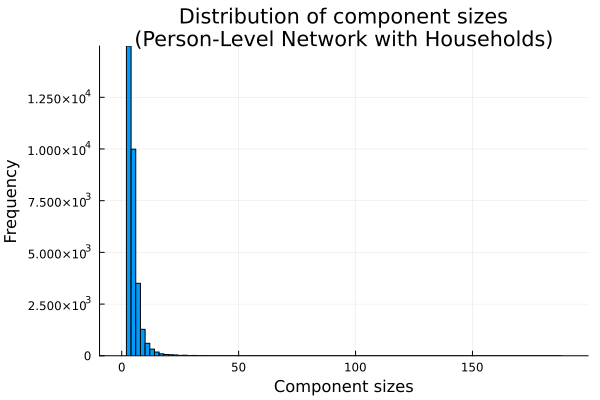

In [ ]:
histogram(PLHH_component_sizes, 
        bins =100, 
        label=nothing,
        xlabel = "Component sizes",
        ylabel = "Frequency",
        title = "Distribution of component sizes\n(Person-Level Network with Households)")

#savefig("Comp_size_PLHHU_Network.png")

In [ ]:
deg_PLHH_Network= degree(PLHH_Network);

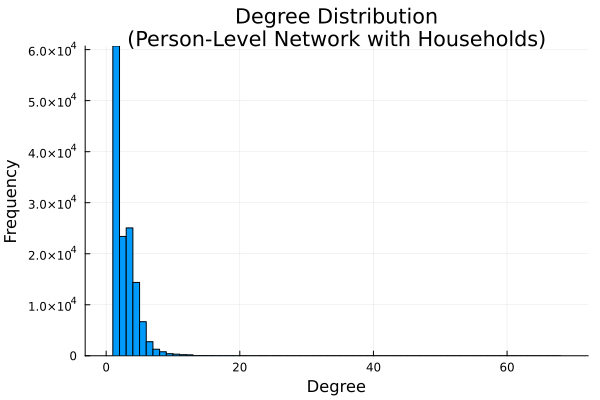

In [ ]:
histogram(
    deg_PLHH_Network,
    bins = 100,
    xlabel = "Degree",
    ylabel = "Frequency",
    label = nothing,
    title = "Degree Distribution\n(Person-Level Network with Households)"
)

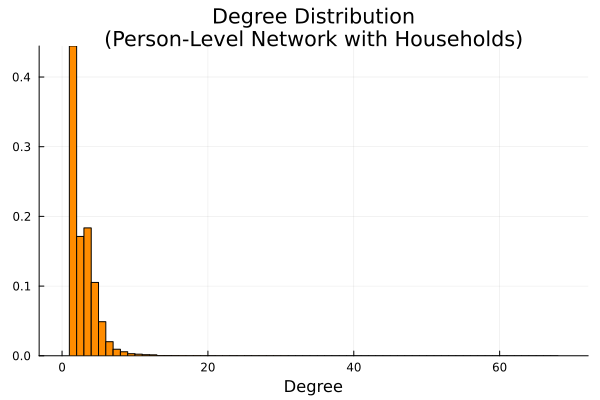

In [ ]:
histogram(
    deg_PLHH_Network,
    bins = 100,
    normalize =:pdf,
    xlabel = "Degree",
    color = :darkorange,
    label = nothing,
    title = "Degree Distribution\n(Person-Level Network with Households)"
)

### Percentage of components that contain any clustering

In [ ]:
n_total = length(PLHH_components)
n_clustered = 0

for comp in PLHH_components
    subg, _ = induced_subgraph(PLHH_Network, comp)

    if nv(subg) >= 3 && global_clustering_coefficient(subg) > 0
        n_clustered += 1
    end
end

pct_clustered_components = 100 * n_clustered / n_total

println("Total components = ", n_total)
println("Clustered components = ", n_clustered)
println("Percentage clustered = ", round(pct_clustered_components, digits=2), "%")

Total components = 31281
Clustered components = 15372
Percentage clustered = 49.14%


### Percentage of clustering that comes from each component

#### Total triangles in the graph

In [ ]:
PLHH_total_triangles = sum(triangles(PLHH_Network)) / 3
println("Total triangles = ", PLHH_total_triangles)

Total triangles = 92747.0


#### Triangle and clustering in each component

In [ ]:
PLHH_comp_stats = DataFrame(
    component_id = Int[],
    size = Int[],
    triangles = Float64[],
    triplets = Float64[],
    pct_of_all_triangles = Float64[], 
    comp_clustering_coeff = Float64[]
)

for (i, comp) in enumerate(PLHH_components)
    subg, _ = induced_subgraph(PLHH_Network, comp)
    ntri = sum(triangles(subg)) / 3
    ntriplets = sum(degree(subg) .* (degree(subg) .- 1)) / 2


    push!(PLHH_comp_stats, (
        i,
        nv(subg),
        ntri,
        ntriplets,
        PLHH_total_triangles == 0 ? 0.0 : 100 * ntri / PLHH_total_triangles,
         global_clustering_coefficient(subg)
    ))
end

In [ ]:
PLHH_comp_stats

Row,component_id,size,triangles,triplets,pct_of_all_triangles,comp_clustering_coeff
,Int64,Int64,Float64,Float64,Float64,Float64
1,1,4,1.0,5.0,0.0010782,0.6
2,2,2,0.0,0.0,0.0,1.0
3,3,14,0.0,67.0,0.0,0.0
4,4,3,0.0,1.0,0.0,0.0
5,5,54,218.0,1071.0,0.235048,0.610644
6,6,9,1.0,18.0,0.0010782,0.166667
7,7,11,42.0,168.0,0.0452845,0.75
8,8,2,0.0,0.0,0.0,1.0
9,9,3,1.0,3.0,0.0010782,1.0


In [ ]:
sort!(PLHH_comp_stats, :pct_of_all_triangles, rev=true)
first(PLHH_comp_stats, 10)

Row,component_id,size,triangles,triplets,pct_of_all_triangles,comp_clustering_coeff
,Int64,Int64,Float64,Float64,Float64,Float64
1,10626,21,969.0,2926.0,1.04478,0.993506
2,14671,41,684.0,2248.0,0.73749,0.912811
3,8520,27,572.0,1995.0,0.616732,0.86015
4,3922,16,560.0,1680.0,0.603793,1.0
5,5773,28,464.0,1469.0,0.500286,0.947583
6,696,34,387.0,2855.0,0.417264,0.406655
7,7910,36,287.0,1017.0,0.309444,0.846608
8,14426,13,286.0,858.0,0.308366,1.0
9,14803,16,275.0,872.0,0.296506,0.946101


In [ ]:
sum(PLHH_comp_stats.triangles)

92747.0

In [ ]:
sum(PLHH_comp_stats.triplets)

477520.0

In [ ]:
# Global clustering Coefficient = (3 * Total Triangles)/Total Triplets
# Triangle - 3 nodes, 3 edges (fully connected)
# Triplet - 3 nodes, 2 edges (connected through a center node)

(3*sum(PLHH_comp_stats.triangles))/sum(PLHH_comp_stats.triplets)

0.5826792595074551

In [ ]:
#global_clustering_coefficient(PLHH_Network)

### For contacts of the same case, how often do contact–contact links exist, conditional on their infection status?

* Infected <-> Infected (YY)

* Infected <-> Susceptible (YN)

* Susceptible <-> Susceptible (NN)

In [ ]:
PLHH_contacts_status_copy = deepcopy(PL_contacts_status);

In [ ]:
rename!(PLHH_contacts_status_copy, :hash_contact_number => :person_id)

Row,person_id,positive
,String,String1
1,0634706e24043278f3c3ff373ee5a231,Y
2,027ffa4193f45c0a4c0833a639be3c7a,N
3,b9d0eb728e1bf14869e743b64db2b2fc,N
4,cfc2fce6117d2412cdd50cf049375124,N
5,3ecd1b19b0569d371cbc8d91bac65094,N
6,89f26b25915eafa733e07112b19e1180,N
7,15cf8627d3ad10861d0c55c7c0a71c1b,N
8,3f2cb5410d85022baf83b917312aa18d,N
9,a1deac33a327567838c02a8bd277fee4,N


In [ ]:
PLHH_status_map = Dict(
    row.person_id => row.positive
    for row in eachrow(PLHH_contacts_status_copy)
)

Dict{String, String1} with 100926 entries:
  "58ac468802be8fed4f5eae4e97c78574" => "N"
  "11440f650b07e988cbad1a94117bca09" => "N"
  "9346d16379dd3d8dbbc84d4d6020cb9d" => "N"
  "da20e200902cb02b7ee9a1c6c32c7f83" => "Y"
  "4fa683df72c141aaf631ac19cad6a52a" => "N"
  "f8e48e080490f403e94f8fb4f9bba3c6" => "Y"
  "5e22a8a2805362536a2f751c93a37f72" => "N"
  "0e133d62f0776c73b94d175193ee8bb2" => "N"
  "bfab3407cf1b8fe06bc09504bf8af799" => "N"
  "6c2ccf9b48bd7eab26217db5533a38b4" => "Y"
  "3d0fc71978ea2675cab119bbdf226bdd" => "N"
  "d4afeb60e87e1aacdbf470e73dca4aae" => "Y"
  "e27bad93143563c93ed0bc789fb5b471" => "Y"
  "3d5506dc6de43722b12d059620e04a3c" => "Y"
  "a78f989eba0a8622f5988e6f078eb348" => "N"
  "59d434dc5dcd31cea3c367b41d47af7b" => "Y"
  "7ec5d8b8819bd42831bfcbf549c3510c" => "N"
  "a222d8c236816e59b577eeab16e968df" => "N"
  "8708df76fcb57081d463cb379afb007b" => "N"
  "92ea875faa8ad8b158569c337d4914dc" => "N"
  "1bf39d56e55d19cd512305deb5b6300b" => "N"
  "a7aa2e4abfc17561b672865391feaa

In [ ]:
PLHH_df_use = df_CCL_Clean

Row,hash_case_number,hash_contact_number,Contact Category,Positive Case,Date Time Entered,GGD_export
,String,String,String3?,String1,String31,String15
1,0000f4abf6b7724542596cb34b0c6a31,0634706e24043278f3c3ff373ee5a231,1,Y,2020-07-28T02:26:00Z,GGD Amsterdam
2,0000f4abf6b7724542596cb34b0c6a31,027ffa4193f45c0a4c0833a639be3c7a,1,N,2020-07-28T02:26:00Z,GGD Amsterdam
3,0000f4abf6b7724542596cb34b0c6a31,b9d0eb728e1bf14869e743b64db2b2fc,2b,N,2020-07-28T02:26:00Z,GGD Amsterdam
4,0001a90c9ba39d1f510170143d2bc06e,cfc2fce6117d2412cdd50cf049375124,2a,N,2020-11-09T18:55:00Z,GGD Amsterdam
5,000429d2cf83d49c90833109faa3c7eb,3ecd1b19b0569d371cbc8d91bac65094,1,N,2021-04-14T19:37:00Z,GGD Amsterdam
6,000429d2cf83d49c90833109faa3c7eb,89f26b25915eafa733e07112b19e1180,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
7,000429d2cf83d49c90833109faa3c7eb,15cf8627d3ad10861d0c55c7c0a71c1b,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
8,000429d2cf83d49c90833109faa3c7eb,3f2cb5410d85022baf83b917312aa18d,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
9,000429d2cf83d49c90833109faa3c7eb,a1deac33a327567838c02a8bd277fee4,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam


In [ ]:
PLHH_counts_total = Dict(
    "YN" => 0,
    "YY" => 0,
    "NN" => 0
)

PLHH_counts_edges = Dict(
    "YN" => 0,
    "YY" => 0,
    "NN" => 0
)

Dict{String, Int64} with 3 entries:
  "YY" => 0
  "YN" => 0
  "NN" => 0

In [ ]:
for subdf in groupby(PLHH_df_use, :hash_case_number)

    contacts = unique(subdf.hash_contact_number)

    # Only consider pairs
    if length(contacts) < 2
        continue
    end

    for (u_id, v_id) in combinations(contacts, 2)

        # Skip if status missing
        if !haskey(PLHH_status_map, u_id) || !haskey(PLHH_status_map, v_id)
            continue
        end

        su = PLHH_status_map[u_id]
        sv = PLHH_status_map[v_id]

        if su == "Y" && sv == "Y"
            key = "YY"
        elseif su == "N" && sv == "N"
            key = "NN"
        else
            key = "YN"
        end

        PLHH_counts_total[key] += 1

        # Check if edge exists in person-level graph
        if has_edge(PLHH_Network, node_map_PL_Network[u_id], node_map_PL_Network[v_id])
            PLHH_counts_edges[key] += 1
        end
    end
end

In [ ]:
PLHH_counts_total

Dict{String, Int64} with 3 entries:
  "YY" => 8663
  "YN" => 37376
  "NN" => 187151

In [ ]:
PLHH_counts_edges

Dict{String, Int64} with 3 entries:
  "YY" => 6439
  "YN" => 14235
  "NN" => 42422

In [ ]:
# Pair type             Interpretation
#    YY            clustering among infected contacts
#    YN            mixing between infected and susceptible
#    NN            clustering among susceptible contacts


println("----- RESULTS -----")

for key in ["YY", "YN", "NN"]
    total = PLHH_counts_total[key]
    edges = PLHH_counts_edges[key]

    prop = total == 0 ? 0.0 : edges / total

    println(key, ": ", round(100 * prop, digits=2), "%")
end

----- RESULTS -----
YY: 74.33%
YN: 38.09%
NN: 22.67%


In [ ]:
# ------------------------------------------------------------
# Stratified pairwise contact analysis by:
#   1) infection status pair: YY, YN, NN
#   2) contact-category pair: 10 unordered combinations
#
# Total configurations = 3 × 10 = 30
# ------------------------------------------------------------

# Assumptions:
# - df_CCL is your links dataset
# - g_person or g_person_aug is your chosen person-level graph
# - node_map maps person ID -> node index in that graph
#

In [ ]:
# ------------------------------------------------------------
# 1. Contact infection-status map
#    One status per contact person
# ------------------------------------------------------------

status_check = combine(
    groupby(PL_df_use, :hash_contact_number),
    "Positive Case" => (x -> length(unique(skipmissing(x)))) => :n_unique_status
)

inconsistent_status = filter(:n_unique_status => >(1), status_check)

if nrow(inconsistent_status) > 0
    error("Some contacts have inconsistent 'Positive Case' values across rows.")
end

PL_contacts_status_spca = combine(
    groupby(PL_df_use, :hash_contact_number),
    "Positive Case" => first => :positive
)

rename!(PL_contacts_status_spca, :hash_contact_number => :person_id)

status_map_spca = Dict(
    row.person_id => row.positive
    for row in eachrow(PL_contacts_status_spca)
)

Dict{String, String1} with 100926 entries:
  "58ac468802be8fed4f5eae4e97c78574" => "N"
  "11440f650b07e988cbad1a94117bca09" => "N"
  "9346d16379dd3d8dbbc84d4d6020cb9d" => "N"
  "da20e200902cb02b7ee9a1c6c32c7f83" => "Y"
  "4fa683df72c141aaf631ac19cad6a52a" => "N"
  "f8e48e080490f403e94f8fb4f9bba3c6" => "Y"
  "5e22a8a2805362536a2f751c93a37f72" => "N"
  "0e133d62f0776c73b94d175193ee8bb2" => "N"
  "bfab3407cf1b8fe06bc09504bf8af799" => "N"
  "6c2ccf9b48bd7eab26217db5533a38b4" => "Y"
  "3d0fc71978ea2675cab119bbdf226bdd" => "N"
  "d4afeb60e87e1aacdbf470e73dca4aae" => "Y"
  "e27bad93143563c93ed0bc789fb5b471" => "Y"
  "3d5506dc6de43722b12d059620e04a3c" => "Y"
  "a78f989eba0a8622f5988e6f078eb348" => "N"
  "59d434dc5dcd31cea3c367b41d47af7b" => "Y"
  "7ec5d8b8819bd42831bfcbf549c3510c" => "N"
  "a222d8c236816e59b577eeab16e968df" => "N"
  "8708df76fcb57081d463cb379afb007b" => "N"
  "92ea875faa8ad8b158569c337d4914dc" => "N"
  "1bf39d56e55d19cd512305deb5b6300b" => "N"
  "a7aa2e4abfc17561b672865391feaa

In [ ]:
# ------------------------------------------------------------
# 1. Contact infection-status map
#    One status per contact person
# ------------------------------------------------------------
# contacts_status = combine(
#     groupby(df_use, :hash_contact_number),
#     "Positive Case" => first => :positive
# )

# PL_contacts_status_spca = deepcopy(PL_contacts_status);

# rename!(PL_contacts_status_spca, :hash_contact_number => :person_id)

# status_map_spca = Dict(
#     row.person_id => row.positive
#     for row in eachrow(PL_contacts_status_spca)
# )

In [ ]:
# ------------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------------

# Infection-status pair: YY, YN, NN
function infection_key(su, sv)
    if su == "Y" && sv == "Y"
        return "YY"
    elseif su == "N" && sv == "N"
        return "NN"
    else
        return "YN"
    end
end

# Contact-category pair: unordered combination
# e.g. (1,2a) and (2a,1) both become "1__2a"
function category_key(cu, cv)
    a, b = sort([String(cu), String(cv)])
    return a * "__" * b
end

# Full 30-group key
full_key(inf_key, cat_key) = inf_key * "__" * cat_key

full_key (generic function with 1 method)

In [ ]:
# ------------------------------------------------------------
# 3. All 30 valid configurations
# ------------------------------------------------------------
cat_levels = ["1", "2a", "2b", "3"]

cat_keys = String[]
for (a, b) in combinations(cat_levels, 2)
    push!(cat_keys, a * "__" * b)
end
for a in cat_levels
    push!(cat_keys, a * "__" * a)
end
sort!(cat_keys)

inf_keys = ["YY", "YN", "NN"]

all_keys = [
    full_key(ik, ck)
    for ik in inf_keys, ck in cat_keys
] |> vec

30-element Vector{String}:
 "YY__1__1"
 "YN__1__1"
 "NN__1__1"
 "YY__1__2a"
 "YN__1__2a"
 "NN__1__2a"
 "YY__1__2b"
 "YN__1__2b"
 "NN__1__2b"
 "YY__1__3"
 "YN__1__3"
 "NN__1__3"
 "YY__2a__2a"
 ⋮
 "YY__2a__3"
 "YN__2a__3"
 "NN__2a__3"
 "YY__2b__2b"
 "YN__2b__2b"
 "NN__2b__2b"
 "YY__2b__3"
 "YN__2b__3"
 "NN__2b__3"
 "YY__3__3"
 "YN__3__3"
 "NN__3__3"

In [ ]:
# ------------------------------------------------------------
# 4. Count totals and observed edges for each configuration
# ------------------------------------------------------------
counts_total = Dict(k => 0 for k in all_keys)
counts_edges = Dict(k => 0 for k in all_keys)

# Optional: also store separate margins
counts_total_inf = Dict(k => 0 for k in inf_keys)
counts_edges_inf = Dict(k => 0 for k in inf_keys)

counts_total_cat = Dict(k => 0 for k in cat_keys)
counts_edges_cat = Dict(k => 0 for k in cat_keys)

Dict{String, Int64} with 10 entries:
  "1__3"   => 0
  "1__1"   => 0
  "1__2a"  => 0
  "2b__2b" => 0
  "3__3"   => 0
  "2a__2a" => 0
  "2a__3"  => 0
  "1__2b"  => 0
  "2b__3"  => 0
  "2a__2b" => 0

In [ ]:
# # ------------------------------------------------------------
# # 5. Main loop over cases, then over pairs of contacts
# # ------------------------------------------------------------
# for subdf in groupby(PL_df_use, :hash_case_number)

#     # keep one row per contact within this case
#     subdf_unique = unique(subdf[:, [:hash_contact_number, Symbol("Contact Category")]])

#     contacts = subdf_unique.hash_contact_number

#     # Need at least 2 contacts to form a pair
#     if length(contacts) < 2
#         continue
#     end

#     # Map contact -> category within this case
#     case_cat_map = Dict(
#         row.hash_contact_number => row[Symbol("Contact Category")]
#         for row in eachrow(subdf_unique)
#     )

#     for (u_id, v_id) in combinations(contacts, 2)

#         # Skip if infection status missing
#         if !haskey(status_map_spca, u_id) || !haskey(status_map_spca, v_id)
#             continue
#         end

#         # Skip if node absent from chosen graph
#         if !haskey(node_map_PL_Network, u_id) || !haskey(node_map_PL_Network, v_id)
#             continue
#         end

#         su = status_map_spca[u_id]
#         sv = status_map_spca[v_id]

#         cu = case_cat_map[u_id]
#         cv = case_cat_map[v_id]

#         ikey = infection_key(su, sv)
#         ckey = category_key(cu, cv)
#         fkey = full_key(ikey, ckey)

#         counts_total[fkey] += 1
#         counts_total_inf[ikey] += 1
#         counts_total_cat[ckey] += 1

#         if has_edge(PL_Network, node_map_PL_Network[u_id], node_map_PL_Network[v_id])
#             counts_edges[fkey] += 1
#             counts_edges_inf[ikey] += 1
#             counts_edges_cat[ckey] += 1
#         end
#     end
# end


In [ ]:
# ------------------------------------------------------------
# 5. Main loop over cases, then over pairs of contacts
# ------------------------------------------------------------
for subdf in groupby(PL_df_use, :hash_case_number)

    # For this case, require one unique category per contact
    case_contact_check = combine(
        groupby(subdf, :hash_contact_number),
        "Contact Category" => (x -> length(unique(skipmissing(x)))) => :n_unique_cat
    )

    inconsistent_contacts = filter(:n_unique_cat => >(1), case_contact_check)

    if nrow(inconsistent_contacts) > 0
        # Skip problematic contacts, or error if you prefer
        bad_contacts = Set(inconsistent_contacts.hash_contact_number)
        subdf_case = subdf[.!in.(subdf.hash_contact_number, Ref(bad_contacts)), :]
    else
        subdf_case = subdf
    end

    # Collapse to one row per contact
    subdf_one = combine(
        groupby(subdf_case, :hash_contact_number),
        "Contact Category" => first => :contact_category
    )

    contacts = subdf_one.hash_contact_number

    # Need at least 2 contacts to form a pair
    if length(contacts) < 2
        continue
    end

    # Map contact -> category within this case
    case_cat_map = Dict(
        row.hash_contact_number => row.contact_category
        for row in eachrow(subdf_one)
    )

    for (u_id, v_id) in combinations(contacts, 2)
        
        # Skip if infection status missing
        if !haskey(status_map_spca, u_id) || !haskey(status_map_spca, v_id)
            continue
        end

        # Skip if node absent from chosen graph
        if !haskey(node_map_PL_Network, u_id) || !haskey(node_map_PL_Network, v_id)
            continue
        end

        su = status_map_spca[u_id]
        sv = status_map_spca[v_id]

        cu = case_cat_map[u_id]
        cv = case_cat_map[v_id]

        ikey = infection_key(su, sv)
        ckey = category_key(cu, cv)
        fkey = full_key(ikey, ckey)

        counts_total[fkey] += 1

        if has_edge(PL_Network, node_map_PL_Network[u_id], node_map_PL_Network[v_id])
            counts_edges[fkey] += 1
        end
    end
end

In [ ]:
# ------------------------------------------------------------
# 6. Convert results to a DataFrame
# ------------------------------------------------------------
results_30 = DataFrame(
    infection_status = String[],
    cat_1 = String[],
    cat_2 = String[],
    total_pairs = Int[],
    connected_pairs = Int[],
    proportion_connected = Float64[]
)

for ikey in inf_keys
    for ckey in cat_keys
        fkey = full_key(ikey, ckey)
        total = counts_total[fkey]
        edges = counts_edges[fkey]
        prop = total == 0 ? 0.0 : edges / total

        cats = split(ckey, "__")

        push!(results_30, (
            ikey,
            cats[1],
            cats[2],
            total,
            edges,
            prop
        ))
    end
end

# Sort for readability
sort!(results_30, [:infection_status, :cat_1, :cat_2])

Row,infection_status,cat_1,cat_2,total_pairs,connected_pairs,proportion_connected
,String,String,String,Int64,Int64,Float64
1,NN,1,1,42420,12,0.000282885
2,NN,1,2a,40512,1,2.4684e-5
3,NN,1,2b,1829,0,0.0
4,NN,1,3,605,0,0.0
5,NN,2a,2a,91389,1,1.09422e-5
6,NN,2a,2b,4624,0,0.0
7,NN,2a,3,1510,0,0.0
8,NN,2b,2b,3515,0,0.0
9,NN,2b,3,294,0,0.0


In [ ]:
# # ------------------------------------------------------------
# # 6. Convert results to a DataFrame
# # ------------------------------------------------------------
# results_30 = DataFrame(
#     infection_status = String[],
#     category_pair = String[],
#     total_pairs = Int[],
#     connected_pairs = Int[],
#     proportion_connected = Float64[]
# )

# for ikey in inf_keys
#     for ckey in cat_keys
#         fkey = full_key(ikey, ckey)
#         total = counts_total[fkey]
#         edges = counts_edges[fkey]
#         prop = total == 0 ? 0.0 : edges / total

#         push!(results_30, (
#             ikey,
#             ckey,
#             total,
#             edges,
#             prop
#         ))
#     end
# end

# # Sort for readability
# sort!(results_30, [:infection_status, :category_pair])

In [ ]:
# # ------------------------------------------------------------
# # 7. Optional: split category pair into two columns
# # ------------------------------------------------------------
# transform!(
#     results_30,
#     :category_pair => ByRow(x -> split(x, "__")[1]) => :cat_1,
#     :category_pair => ByRow(x -> split(x, "__")[2]) => :cat_2
# )

# select!(results_30,
#     :infection_status, :cat_1, :cat_2,
#     :total_pairs, :connected_pairs, :proportion_connected
# )

In [ ]:
# ------------------------------------------------------------
# 8. Display / inspect
# ------------------------------------------------------------
println(results_30)

30×6 DataFrame
 Row │ infection_status  cat_1   cat_2   total_pairs  connected_pairs  proportion_connected 
     │ String            String  String  Int64        Int64            Float64              
─────┼──────────────────────────────────────────────────────────────────────────────────────
   1 │ NN                1       1             42420               12           0.000282885
   2 │ NN                1       2a            40512                1           2.4684e-5
   3 │ NN                1       2b             1829                0           0.0
   4 │ NN                1       3               605                0           0.0
   5 │ NN                2a      2a            91389                1           1.09422e-5
   6 │ NN                2a      2b             4624                0           0.0
   7 │ NN                2a      3              1510                0           0.0
   8 │ NN                2b      2b             3515                0           0.0
   9 │ NN    

In [ ]:
# Optional: percentage version
results_30.percentage_connected = 100 .* results_30.proportion_connected

30-element Vector{Float64}:
  0.028288543140028287
  0.0024684044233807267
  0.0
  0.0
  0.0010942235936491262
  0.0
  0.0
  0.0
  0.0
  0.0
 64.85136147889084
  7.753411636906783
  4.770318021201414
  ⋮
  0.0
  0.0
 45.61254046685977
 15.778546712802768
 31.428571428571427
  0.0
 25.68881685575365
 12.903225806451612
 28.57142857142857
 40.0
  0.0
  0.0

In [ ]:
sort(results_30.percentage_connected)

30-element Vector{Float64}:
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0010942235936491262
  ⋮
  6.046511627906977
  7.753411636906783
  9.574468085106384
 11.071116928446772
 12.903225806451612
 15.778546712802768
 25.68881685575365
 28.57142857142857
 31.428571428571427
 40.0
 45.61254046685977
 64.85136147889084

In [ ]:
# ------------------------------------------------------------
# 9. Summary tables built from results_30
# ------------------------------------------------------------


# By infection status only
results_by_infection = combine(
    groupby(results_30, :infection_status),
    :total_pairs => sum => :total_pairs,
    :connected_pairs => sum => :connected_pairs
)

results_by_infection.proportion_connected = [
    tp == 0 ? 0.0 : cp / tp
    for (tp, cp) in zip(results_by_infection.total_pairs,
                        results_by_infection.connected_pairs)
]

results_by_infection.percentage_connected =
    100 .* results_by_infection.proportion_connected

sort!(results_by_infection, :infection_status)

# By category pair only
results_by_category = combine(
    groupby(results_30, [:cat_1, :cat_2]),
    :total_pairs => sum => :total_pairs,
    :connected_pairs => sum => :connected_pairs
)

results_by_category.proportion_connected = [
    tp == 0 ? 0.0 : cp / tp
    for (tp, cp) in zip(results_by_category.total_pairs,
                        results_by_category.connected_pairs)
]

results_by_category.percentage_connected =
    100 .* results_by_category.proportion_connected

sort!(results_by_category, [:cat_1, :cat_2])

Row,cat_1,cat_2,total_pairs,connected_pairs,proportion_connected,percentage_connected
,String,String,Int64,Int64,Float64,Float64
1,1,1,60298,10477,0.173754,17.3754
2,1,2a,56686,1371,0.0241859,2.41859
3,1,2b,2430,38,0.0156379,1.56379
4,1,3,836,13,0.0155502,1.55502
5,2a,2a,101791,1333,0.0130955,1.30955
6,2a,2b,5035,22,0.00436941,0.436941
7,2a,3,1723,8,0.00464306,0.464306
8,2b,2b,3619,13,0.00359215,0.359215
9,2b,3,298,0,0.0,0.0


In [ ]:
# # ------------------------------------------------------------
# # 9. Optional summary tables
# # ------------------------------------------------------------

# # By infection status only
# results_by_infection = DataFrame(
#     infection_status = inf_keys,
#     total_pairs = [counts_total_inf[k] for k in inf_keys],
#     connected_pairs = [counts_edges_inf[k] for k in inf_keys]
# )
# results_by_infection.proportion_connected =
#     results_by_infection.connected_pairs ./ results_by_infection.total_pairs

# # By category pair only
# results_by_category = DataFrame(
#     category_pair = cat_keys,
#     total_pairs = [counts_total_cat[k] for k in cat_keys],
#     connected_pairs = [counts_edges_cat[k] for k in cat_keys]
# )
# results_by_category.proportion_connected =
#     results_by_category.connected_pairs ./ results_by_category.total_pairs


In [ ]:
results_by_infection

Row,infection_status,total_pairs,connected_pairs,proportion_connected,percentage_connected
,String,Int64,Int64,Float64,Float64
1,NN,187151,14,7.48059e-5,0.00748059
2,YN,37376,10014,0.267926,26.7926
3,YY,8663,3247,0.374812,37.4812


In [ ]:
results_by_category

Row,cat_1,cat_2,total_pairs,connected_pairs,proportion_connected,percentage_connected
,String,String,Int64,Int64,Float64,Float64
1,1,1,60298,10477,0.173754,17.3754
2,1,2a,56686,1371,0.0241859,2.41859
3,1,2b,2430,38,0.0156379,1.56379
4,1,3,836,13,0.0155502,1.55502
5,2a,2a,101791,1333,0.0130955,1.30955
6,2a,2b,5035,22,0.00436941,0.436941
7,2a,3,1723,8,0.00464306,0.464306
8,2b,2b,3619,13,0.00359215,0.359215
9,2b,3,298,0,0.0,0.0


In [ ]:
42420+12010+4869

59299

In [ ]:
12+7788+2677

10477

In [ ]:
# ------------------------------------------------------------
# 10. Optional: save results
# ------------------------------------------------------------
# using CSV
# CSV.write("results_30_stratified_configurations.csv", results_30)
# CSV.write("results_by_infection.csv", results_by_infection)
# CSV.write("results_by_category.csv", results_by_category)

In [ ]:
g_bip

{152775, 125623} undirected simple Int64 graph

In [ ]:
df_CCL_copy_1 = deepcopy(df_CCL)

Row,hash_case_number,hash_contact_number,Contact Category,Positive Case,Date Time Entered,GGD_export
,String,String,String3?,String1,String31,String15
1,0000f4abf6b7724542596cb34b0c6a31,0634706e24043278f3c3ff373ee5a231,1,Y,2020-07-28T02:26:00Z,GGD Amsterdam
2,0000f4abf6b7724542596cb34b0c6a31,027ffa4193f45c0a4c0833a639be3c7a,1,N,2020-07-28T02:26:00Z,GGD Amsterdam
3,0000f4abf6b7724542596cb34b0c6a31,b9d0eb728e1bf14869e743b64db2b2fc,2b,N,2020-07-28T02:26:00Z,GGD Amsterdam
4,0001a90c9ba39d1f510170143d2bc06e,cfc2fce6117d2412cdd50cf049375124,2a,N,2020-11-09T18:55:00Z,GGD Amsterdam
5,000429d2cf83d49c90833109faa3c7eb,3ecd1b19b0569d371cbc8d91bac65094,1,N,2021-04-14T19:37:00Z,GGD Amsterdam
6,000429d2cf83d49c90833109faa3c7eb,89f26b25915eafa733e07112b19e1180,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
7,000429d2cf83d49c90833109faa3c7eb,15cf8627d3ad10861d0c55c7c0a71c1b,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
8,000429d2cf83d49c90833109faa3c7eb,3f2cb5410d85022baf83b917312aa18d,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam
9,000429d2cf83d49c90833109faa3c7eb,a1deac33a327567838c02a8bd277fee4,2a,N,2021-04-14T19:37:00Z,GGD Amsterdam


In [ ]:
df_CCL_copy_1."Date Parsed" = DateTime.(df_CCL_copy_1."Date Time Entered", dateformat"yyyy-mm-ddTHH:MM:SSZ")
df_CCL_copy_1."Date" = Date.(df_CCL_copy_1."Date Parsed")
select!(df_CCL_copy_1, Not(Symbol("Date Parsed")));

In [ ]:
sort!(df_CCL_copy_1, :"Date")

Row,hash_case_number,hash_contact_number,Contact Category,Positive Case,Date Time Entered,GGD_export,Date
,String,String,String3?,String1,String31,String15,Date
1,6c9883794cb76dcf31095e82a173347e,03b7c21b50c38d2847fea3bdce390b63,missing,Y,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14
2,6c9883794cb76dcf31095e82a173347e,607a65656d3b025ab097179fd3ebae5d,missing,N,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14
3,6c9883794cb76dcf31095e82a173347e,ef372af7fbf7e952e24e890f86c5563e,missing,N,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14
4,6c9883794cb76dcf31095e82a173347e,7b4e1158e274dc49da8997bfee7a915a,missing,N,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14
5,6c9883794cb76dcf31095e82a173347e,cb4487aa00079e525ab3d81096f4b494,missing,N,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14
6,6c9883794cb76dcf31095e82a173347e,9bd17fa683db668bda14d9e503192f20,missing,N,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14
7,6c9883794cb76dcf31095e82a173347e,605af8a37196cfa993a4c9cb2afbde56,missing,Y,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14
8,6c9883794cb76dcf31095e82a173347e,390936e5ad05631834fabb5a809c9aa4,missing,N,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14
9,6c9883794cb76dcf31095e82a173347e,d2a7ed02e195c465c2f2d49c8f15dd33,missing,N,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14


In [ ]:
earliest_date = minimum(df_CCL_copy_1."Date")
latest_date   = maximum(df_CCL_copy_1."Date");

In [ ]:
earliest_date

2020-06-14

In [ ]:
latest_date

2021-05-30

In [ ]:
latest_date - earliest_date

350 days

In [ ]:
Date(2021, 5, 21) + Day(9)

2021-05-30

In [ ]:
start_date = Date(2020, 6, 14)
final_date = Date(2021, 5, 30)

window_size = Day(60)

dfs_days = DataFrame[]
window_info = []

current_start = start_date
window_number = 1

while current_start <= final_date
    current_end = min(current_start + window_size, final_date + Day(1))

    df_subset = df_CCL_copy_1[
        (df_CCL_copy_1."Date" .>= current_start) .&
        (df_CCL_copy_1."Date" .< current_end),
        :
    ]

    push!(dfs_days, df_subset)
    push!(window_info, (
        window = window_number,
        start = current_start,
        end_inclusive = current_end - Day(1),
        nrows = nrow(df_subset)
    ))

    current_start = current_end
    window_number += 1
end

In [ ]:
dfs_days[1]

Row,hash_case_number,hash_contact_number,Contact Category,Positive Case,Date Time Entered,GGD_export,Date
,String,String,String3?,String1,String31,String15,Date
1,6c9883794cb76dcf31095e82a173347e,03b7c21b50c38d2847fea3bdce390b63,missing,Y,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14
2,6c9883794cb76dcf31095e82a173347e,607a65656d3b025ab097179fd3ebae5d,missing,N,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14
3,6c9883794cb76dcf31095e82a173347e,ef372af7fbf7e952e24e890f86c5563e,missing,N,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14
4,6c9883794cb76dcf31095e82a173347e,7b4e1158e274dc49da8997bfee7a915a,missing,N,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14
5,6c9883794cb76dcf31095e82a173347e,cb4487aa00079e525ab3d81096f4b494,missing,N,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14
6,6c9883794cb76dcf31095e82a173347e,9bd17fa683db668bda14d9e503192f20,missing,N,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14
7,6c9883794cb76dcf31095e82a173347e,605af8a37196cfa993a4c9cb2afbde56,missing,Y,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14
8,6c9883794cb76dcf31095e82a173347e,390936e5ad05631834fabb5a809c9aa4,missing,N,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14
9,6c9883794cb76dcf31095e82a173347e,d2a7ed02e195c465c2f2d49c8f15dd33,missing,N,2020-06-14T18:51:00Z,GGD Amsterdam,2020-06-14


In [ ]:
countmap(dfs_days[1].var"Contact Category")

Dict{Union{Missing, String3}, Int64} with 5 entries:
  String3("2a") => 7138
  missing       => 1692
  String3("1")  => 15032
  String3("2b") => 518
  String3("3")  => 223

In [ ]:
start_date = Date(2020, 6, 14)
final_date = Date(2021, 5, 30)

dfs_monthly = DataFrame[]
window_info = []

current_start = start_date
window_number = 1

while current_start <= final_date
    # First day of next month
    next_month_start = firstdayofmonth(current_start) + Month(1)

    # End of current window, respecting final_date
    current_end = min(next_month_start, final_date + Day(1))

    df_subset = df_CCL_copy_1[
        (df_CCL_copy_1."Date" .>= current_start) .&
        (df_CCL_copy_1."Date" .< current_end),
        :
    ]

    push!(dfs_monthly, df_subset)
    push!(window_info, (
        window = window_number,
        start = current_start,
        end_inclusive = current_end - Day(1),
        month_label = Dates.format(current_start, "yyyy-mm"),
        nrows = nrow(df_subset)
    ))

    current_start = current_end
    window_number += 1
end

In [ ]:
DataFrame(window_info)

Row,window,start,end_inclusive,month_label,nrows
,Int64,Date,Date,String,Int64
1,1,2020-06-14,2020-06-30,2020-06,665
2,2,2020-07-01,2020-07-31,2020-07,2319
3,3,2020-08-01,2020-08-31,2020-08,4702
4,4,2020-09-01,2020-09-30,2020-09,10103
5,5,2020-10-01,2020-10-31,2020-10,4185
6,6,2020-11-01,2020-11-30,2020-11,21115
7,7,2020-12-01,2020-12-31,2020-12,23602
8,8,2021-01-01,2021-01-31,2021-01,13668
9,9,2021-02-01,2021-02-28,2021-02,10670


In [ ]:
dfs_monthly[12]

Row,hash_case_number,hash_contact_number,Contact Category,Positive Case,Date Time Entered,GGD_export,Date
,String,String,String3?,String1,String31,String15,Date
1,0546d82f9b8caa1acca6be3676d586df,10d3304974e404b8bef85f15f0392592,1,N,2021-05-01T13:25:00Z,GGD Amsterdam,2021-05-01
2,0546d82f9b8caa1acca6be3676d586df,f06c35fdb75c41f7c5d450f8ee6d946c,2a,N,2021-05-01T13:25:00Z,GGD Amsterdam,2021-05-01
3,0588ceaeb290ca351bf5d394ffdbbea9,f9d3197a699fc77323d128796c933704,1,N,2021-05-01T14:19:00Z,GGD Amsterdam,2021-05-01
4,078255c776aaff1c3aa050ec5a812d31,a961a47d183276d6898cf5766938f0c5,missing,Y,2021-05-01T16:25:00Z,GGD Amsterdam,2021-05-01
5,0d88f7b276752529db25a019dea56f92,a111c19ac63f840c78a7ef061e9a1158,1,N,2021-05-01T17:46:00Z,GGD Amsterdam,2021-05-01
6,0d88f7b276752529db25a019dea56f92,ea113b356519ba8ba80cd024f9e67840,1,N,2021-05-01T17:46:00Z,GGD Amsterdam,2021-05-01
7,0d88f7b276752529db25a019dea56f92,865db827ff25c256e189cd5543caf5eb,1,N,2021-05-01T17:46:00Z,GGD Amsterdam,2021-05-01
8,10b2c043ac6ce703445304444eab5df4,a341e873857661ee1b1860c35f8fe748,1,N,2021-05-01T13:21:00Z,GGD Amsterdam,2021-05-01
9,11659aecb7a3c28cdc3db98b06f10f47,f84690ac5cddbe8525cd451cd9389cc4,1,N,2021-05-01T13:39:00Z,GGD Amsterdam,2021-05-01


In [ ]:
countmap(dfs_monthly[12].var"Contact Category")

Dict{Union{Missing, String3}, Int64} with 5 entries:
  String3("1")  => 5312
  String3("2a") => 2896
  missing       => 372
  String3("2b") => 78
  String3("3")  => 8

In [124]:

df_CCL_copy_2 = deepcopy(df_CCL)

# Ensure Date column exists
df_CCL_copy_2."Date" = Date.(DateTime.(df_CCL_copy_2."Date Time Entered",
    dateformat"yyyy-mm-ddTHH:MM:SSZ"))

125623-element Vector{Date}:
 2020-07-28
 2020-07-28
 2020-07-28
 2020-11-09
 2021-04-14
 2021-04-14
 2021-04-14
 2021-04-14
 2021-04-14
 2021-04-14
 2021-04-14
 2021-04-14
 2021-04-14
 ⋮
 2020-11-21
 2020-12-13
 2020-12-13
 2020-12-13
 2020-09-09
 2020-09-09
 2020-09-09
 2020-09-09
 2020-12-13
 2021-02-08
 2021-02-08
 2021-02-08

In [125]:
df_CCL_copy_2.month = Date.(year.(df_CCL_copy_2."Date"), month.(df_CCL_copy_2."Date"), 1)

125623-element Vector{Date}:
 2020-07-01
 2020-07-01
 2020-07-01
 2020-11-01
 2021-04-01
 2021-04-01
 2021-04-01
 2021-04-01
 2021-04-01
 2021-04-01
 2021-04-01
 2021-04-01
 2021-04-01
 ⋮
 2020-11-01
 2020-12-01
 2020-12-01
 2020-12-01
 2020-09-01
 2020-09-01
 2020-09-01
 2020-09-01
 2020-12-01
 2021-02-01
 2021-02-01
 2021-02-01

In [126]:
monthly_stats = combine(groupby(df_CCL_copy_2, :month)) do subdf
    total = nrow(subdf)

    household = sum(coalesce.(subdf."Contact Category", "") .== "1")

    missing_count = sum(
        ismissing.(subdf."Contact Category") .|
        (coalesce.(subdf."Contact Category", "") .== "missing")
    )

    (
        total_contacts = total,
        household_prop = total == 0 ? 0.0 : household / total,
        missing_prop = total == 0 ? 0.0 : missing_count / total
    )
end

Row,month,total_contacts,household_prop,missing_prop
,Date,Int64,Float64,Float64
1,2020-07-01,2319,0.354463,0.080207
2,2020-11-01,21115,0.654464,0.00279422
3,2021-04-01,11515,0.687277,0.00555797
4,2021-01-01,13668,0.61194,0.0008048
5,2021-05-01,8666,0.61297,0.0429264
6,2020-10-01,4185,0.383035,0.390442
7,2020-12-01,23602,0.601559,0.00114397
8,2021-03-01,14413,0.593353,0.000416291
9,2020-08-01,4702,0.311357,0.167801


In [127]:
sort!(monthly_stats, :month)

Row,month,total_contacts,household_prop,missing_prop
,Date,Int64,Float64,Float64
1,2020-06-01,665,0.148872,0.66015
2,2020-07-01,2319,0.354463,0.080207
3,2020-08-01,4702,0.311357,0.167801
4,2020-09-01,10103,0.383846,0.231119
5,2020-10-01,4185,0.383035,0.390442
6,2020-11-01,21115,0.654464,0.00279422
7,2020-12-01,23602,0.601559,0.00114397
8,2021-01-01,13668,0.61194,0.0008048
9,2021-02-01,10670,0.576664,0.00253046


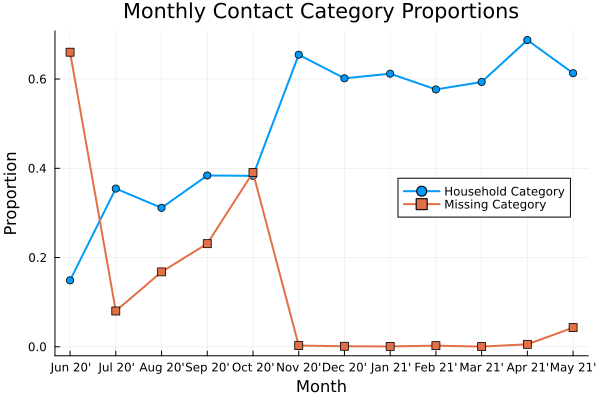

In [128]:
x = 1:nrow(monthly_stats)
labels = Dates.format.(monthly_stats.month, "u yy'")

plot(
    x,
    monthly_stats.household_prop,
    label = "Household Category",
    lw = 2,
    marker = :circle,
    legend = :right
)

plot!(
    x,
    monthly_stats.missing_prop,
    label = "Missing Category",
    lw = 2,
    marker = :square
)

xticks!(x, labels)
xlabel!("Month")
ylabel!("Proportion")
title!("Monthly Contact Category Proportions")
#savefig("Prop_Contact_Categories.png")

In [129]:
# df = deepcopy(df_CCL)

# # If needed, create Date column from Date Time Entered
# df."Date" = Date.(DateTime.(df."Date Time Entered", dateformat"yyyy-mm-ddTHH:MM:SSZ"))

# # Create month variable
# df.month = Date.(year.(df."Date"), month.(df."Date"), 1)

monthly_stats = combine(groupby(df_CCL_copy_2, :month)) do subdf
    total = nrow(subdf)

    cat = subdf."Contact Category"

    household = sum(coalesce.(cat, "") .== "1")

    missing_count = sum(
        ismissing.(cat) .| (coalesce.(cat, "") .== "missing")
    )

    nonmissing_count = total - missing_count

    (
        total_contacts = total,
        household_count = household,
        missing_count = missing_count,
        nonmissing_count = nonmissing_count,
        household_prop_total = total == 0 ? 0.0 : household / total,
        missing_prop_total = total == 0 ? 0.0 : missing_count / total,
        household_prop_nonmissing = nonmissing_count == 0 ? 0.0 : household / nonmissing_count
    )
end

sort!(monthly_stats, :month)

Row,month,total_contacts,household_count,missing_count,nonmissing_count,household_prop_total,missing_prop_total,household_prop_nonmissing
,Date,Int64,Int64,Int64,Int64,Float64,Float64,Float64
1,2020-06-01,665,99,439,226,0.148872,0.66015,0.438053
2,2020-07-01,2319,822,186,2133,0.354463,0.080207,0.385373
3,2020-08-01,4702,1464,789,3913,0.311357,0.167801,0.374137
4,2020-09-01,10103,3878,2335,7768,0.383846,0.231119,0.499228
5,2020-10-01,4185,1603,1634,2551,0.383035,0.390442,0.628381
6,2020-11-01,21115,13819,59,21056,0.654464,0.00279422,0.656297
7,2020-12-01,23602,14198,27,23575,0.601559,0.00114397,0.602248
8,2021-01-01,13668,8364,11,13657,0.61194,0.0008048,0.612433
9,2021-02-01,10670,6153,27,10643,0.576664,0.00253046,0.578126


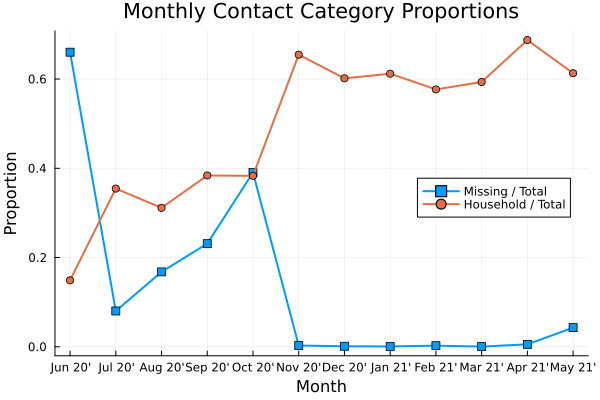

In [141]:
x = 1:nrow(monthly_stats)
labels = Dates.format.(monthly_stats.month, "u yy'")

plot(
    x,
    monthly_stats.missing_prop_total,
    label = "Missing / Total",
    lw = 2,
    marker = :square,
    legend = :right
)

plot!(
    x,
    monthly_stats.household_prop_total,
    label = "Household / Total",
    lw = 2,
    marker = :circle
)


xticks!(x, labels)
xlabel!("Month")
ylabel!("Proportion")
title!("Monthly Contact Category Proportions")
#savefig("Prop_Contact_Categories_1.png")

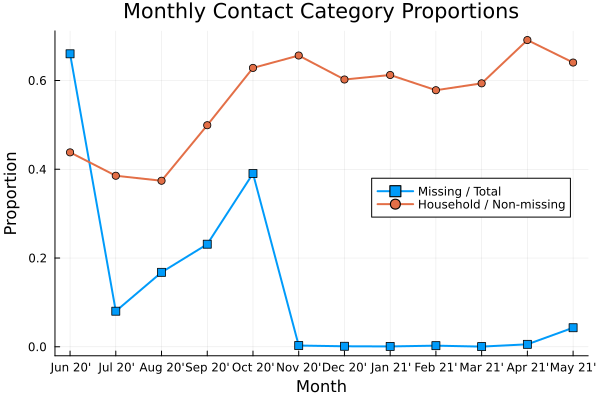

In [144]:
x = 1:nrow(monthly_stats)
labels = Dates.format.(monthly_stats.month, "u yy'")


plot(
    x,
    monthly_stats.missing_prop_total,
    label = "Missing / Total",
    lw = 2,
    marker = :square,
    legend = :right
)

plot!(
    x,
    monthly_stats.household_prop_nonmissing,
    label = "Household / Non-missing",
    lw = 2,
    marker = :circle
)

xticks!(x, labels)
xlabel!("Month")
ylabel!("Proportion")
title!("Monthly Contact Category Proportions")
#savefig("Prop_Contact_Categories_2.png")

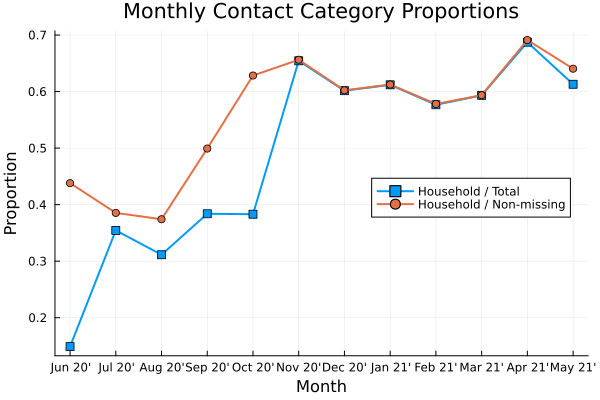

In [147]:
x = 1:nrow(monthly_stats)
labels = Dates.format.(monthly_stats.month, "u yy'")


plot(
    x,
    monthly_stats.household_prop_total,
    label = "Household / Total",
    lw = 2,
    marker = :square,
    legend = :right
)

plot!(
    x,
    monthly_stats.household_prop_nonmissing,
    label = "Household / Non-missing",
    lw = 2,
    marker = :circle
)

xticks!(x, labels)
xlabel!("Month")
ylabel!("Proportion")
title!("Monthly Contact Category Proportions")
#savefig("Prop_Contact_Categories_3.png")

In [ ]:
df_CT_Contextual

Row,Date,CT tier (see note),Stringency index,CaseLoad,FTE,Load/FTE
,Date,Float64?,Float64,Int64,Int64,Float64
1,2020-06-01,missing,62.96,114,26,4.38462
2,2020-06-02,missing,62.96,114,26,4.38462
3,2020-06-03,missing,62.96,114,26,4.38462
4,2020-06-04,missing,62.96,114,26,4.38462
5,2020-06-05,missing,62.96,114,26,4.38462
6,2020-06-06,missing,62.96,114,26,4.38462
7,2020-06-07,missing,62.96,114,26,4.38462
8,2020-06-08,missing,62.96,114,26,4.38462
9,2020-06-09,missing,62.96,114,26,4.38462


In [ ]:
minimum(df_CT_Contextual."Date")

2020-06-01

In [ ]:
maximum(df_CT_Contextual."Date")

2021-02-28

In [ ]:
df_CT_Contextual.var"Stringency index"

273-element Vector{Float64}:
 62.96
 62.96
 62.96
 62.96
 62.96
 62.96
 62.96
 62.96
 62.96
 62.96
 62.96
 62.96
 62.96
  ⋮
 78.7
 78.7
 78.7
 78.7
 78.7
 78.7
 78.7
 78.7
 78.7
 78.7
 78.7
 78.7

In [13]:
df_RIVM_Data

Row,Version,Date_of_report,Date_of_publication,Security_region_name,Security_region_code,Source_and_contact_tracing_phase,Total_reported,Reports_with_settings,Setting_reported,Number_settings_reported
,Int64,String31,Date,String31,String15,String7,Int64,Int64,String31,Int64
1,5,2022-08-09 10:00:00,2020-12-14,Groningen,VR01,low,-9999,-9999,-9999,-9999
2,5,2022-08-09 10:00:00,2020-12-14,Fryslân,VR02,low,-9999,-9999,-9999,-9999
3,5,2022-08-09 10:00:00,2020-12-14,Drenthe,VR03,medium,-9999,-9999,-9999,-9999
4,5,2022-08-09 10:00:00,2020-12-14,IJsselland,VR04,medium,-9999,-9999,-9999,-9999
5,5,2022-08-09 10:00:00,2020-12-14,Twente,VR05,low,-9999,-9999,-9999,-9999
6,5,2022-08-09 10:00:00,2020-12-14,Noord- en Oost-Gelderland,VR06,medium,-9999,-9999,-9999,-9999
7,5,2022-08-09 10:00:00,2020-12-14,Gelderland-Midden,VR07,medium,-9999,-9999,-9999,-9999
8,5,2022-08-09 10:00:00,2020-12-14,Gelderland-Zuid,VR08,low,-9999,-9999,-9999,-9999
9,5,2022-08-09 10:00:00,2020-12-14,Utrecht,VR09,medium,-9999,-9999,-9999,-9999


In [14]:
df_RIVM_Data.Setting_reported

54799-element PooledArrays.PooledVector{String31, UInt32, Vector{UInt32}}:
 "-9999"
 "-9999"
 "-9999"
 "-9999"
 "-9999"
 "-9999"
 "-9999"
 "-9999"
 "-9999"
 "-9999"
 "-9999"
 "-9999"
 "home"
 ⋮
 "-9999"
 "-9999"
 "-9999"
 "-9999"
 "-9999"
 "-9999"
 "-9999"
 "-9999"
 "-9999"
 "-9999"
 "-9999"
 "-9999"

In [18]:
countmap(df_RIVM_Data.Setting_reported)

Dict{String31, Int64} with 22 entries:
  "home"                      => 5478
  "travel"                    => 2071
  "general_practitioner"      => 781
  "residential_care_other"    => 1413
  "residential_care_disabled" => 1518
  "student_activity"          => 575
  "daycare_elderly_disabled"  => 1107
  "funeral"                   => 826
  "hospital"                  => 1778
  "health_care_other"         => 1924
  "visit"                     => 5254
  "gathering"                 => 2695
  "work"                      => 4896
  "-9999"                     => 9040
  "religious_activity"        => 739
  "nursing_home"              => 2839
  "school_daycare"            => 4144
  "leisure"                   => 1577
  "hospitality"               => 1585
  "flight"                    => 692
  "other"                     => 3774
  "choir"                     => 93

In [19]:
5478/54799

0.09996532783444953